In [1]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
import warnings
#from pingouin import ancova
#import pingouin as pg
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
import matplotlib.pyplot as plt
# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.max_rows = 20

### Note: Make sure you're using an environment with Seaborn >= 0.13

# Overview

The CSV files that are input into this Jupyter notebook are Olink Analyze GSEA results produced by the Olink_GSEA_results.Rmd and Olink_GSEA_results_adrenic_acid.Rmd scripts.  All GSEA results input here are Python dataframes that have adjusted p-value scores <0.05. The values in the description columns have been cleaned for easier interpretation. 

The Normalized Enrichment Score (NES) for each pathway is visualized in a bubble plot where the size of the circle corresponds to the setSize column.

The core_enrichment column contains the names of genes in the making up the leading edge of the enrichment. Each enriched pathway from the GSEA had a list of core enrichment biomarkers (leading edge genes) that contributed most to the enrichment score and are ordered relative to magnitude of change between the two conditions. For each exposure, the list of enriched pathways were collated and core enrichment biomarkers found in at least 50% of the pathways were retained and listed in Table 1 (code to generate them is below). These biomarkers were manually-curated with citations supporting known associations with asthma, particularly asthma endotypes including T2-high, T2-low, and T1-high – an emerging subset of T2-low asthma (Supplementary table 3). 





# Analysis of DEHP associations with pathways at 1 and 5 year

In [ ]:
olink_1y_dehp_upper_quartile = pd.read_csv("olink_1y_dehp_upper_quartile.csv")
olink_1y_dehp_upper_quartile['visit']='1 Year'


In [ ]:
olink_5y_dehp_upper_quartile = pd.read_csv("olink_5y_dehp_upper_quartile.csv")
olink_5y_dehp_upper_quartile['visit']='5 Years'

In [ ]:
dataframes = [olink_1y_dehp_upper_quartile,olink_5y_dehp_upper_quartile]

olink_1y_and_5y_dehp_upper_quartile = pd.concat(dataframes)


In [ ]:
olink_1y_and_5y_dehp_upper_quartile.sort_values(by="NES",inplace=True)
olink_1y_and_5y_dehp_upper_quartile.reset_index(drop=True, inplace=True)

In [ ]:
# Invert the sign of the NES column because the original olink_pathway_analysis provides the direction of up/down regulation of the pathway relative to the treatment
olink_1y_and_5y_dehp_upper_quartile['NES'] = olink_1y_and_5y_dehp_upper_quartile['NES'] * -1


In [ ]:
olink_1y_and_5y_dehp_upper_quartile.sort_values(by="Description")

,Unnamed: 0,exposure,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,visit
22,GOBP_ANTIMICROBIAL_HUMORAL_IMMUNE_RESPONSE_MED...,Dust DEHP in upper quartile,GOBP_ANTIMICROBIAL_HUMORAL_IMMUNE_RESPONSE_MED...,GOBP_ANTIMICROBIAL_HUMORAL_IMMUNE_RESPONSE_MED...,22,0.729276,-1.898783,0.000115,0.012559,0.011162,14,"tags=50%, list=15%, signal=56%",CCL7/CCL2/CCL20/CCL25/CXCL5/CXCL1/CXCL11/CXCL9...,5 Years
23,GOBP_ANTIMICROBIAL_HUMORAL_RESPONSE,Dust DEHP in upper quartile,GOBP_ANTIMICROBIAL_HUMORAL_RESPONSE,GOBP_ANTIMICROBIAL_HUMORAL_RESPONSE,22,0.729276,-1.898783,0.000115,0.012559,0.011162,14,"tags=50%, list=15%, signal=56%",CCL7/CCL2/CCL20/CCL25/CXCL5/CXCL1/CXCL11/CXCL9...,5 Years
7,GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECI...,Dust DEHP in upper quartile,GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECI...,GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECI...,45,0.613201,-1.759637,0.000918,0.022893,0.020347,17,"tags=33%, list=18%, signal=53%",CCL7/CCL2/CCL20/CCL25/CXCL5/IL10RA/CXCL1/CXCL1...,5 Years
17,GOBP_CELL_CHEMOTAXIS,Dust DEHP in upper quartile,GOBP_CELL_CHEMOTAXIS,GOBP_CELL_CHEMOTAXIS,28,0.692989,-1.881918,0.000172,0.012559,0.011162,15,"tags=46%, list=16%, signal=56%",CCL7/CCL2/CCL20/CCL25/CXCL5/CXCL1/CXCL11/CXCL9...,5 Years
9,GOBP_CELL_KILLING,Dust DEHP in upper quartile,GOBP_CELL_KILLING,GOBP_CELL_KILLING,19,0.714213,-1.797703,0.001495,0.028814,0.025609,14,"tags=47%, list=15%, signal=51%",CCL20/CCL25/CXCL1/CXCL11/CXCL9/CCL11/IL10/CXCL...,5 Years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,REACTOME_PEPTIDE_LIGAND_BINDING_RECEPTORS,Dust DEHP in upper quartile,REACTOME_PEPTIDE_LIGAND_BINDING_RECEPTORS,REACTOME_PEPTIDE_LIGAND_BINDING_RECEPTORS,19,0.739882,-1.862314,0.000478,0.012678,0.011268,14,"tags=58%, list=15%, signal=62%",CCL7/CCL2/CCL20/CCL25/CXCL5/CXCL1/CXCL11/CXCL9...,5 Years
13,REACTOME_SIGNALING_BY_GPCR,Dust DEHP in upper quartile,REACTOME_SIGNALING_BY_GPCR,REACTOME_SIGNALING_BY_GPCR,19,0.739882,-1.862314,0.000478,0.012678,0.011268,14,"tags=58%, list=15%, signal=62%",CCL7/CCL2/CCL20/CCL25/CXCL5/CXCL1/CXCL11/CXCL9...,5 Years
24,SANA_TNF_SIGNALING_UP,Dust DEHP in upper quartile,SANA_TNF_SIGNALING_UP,SANA_TNF_SIGNALING_UP,12,0.833547,-1.908212,0.000071,0.012559,0.011162,14,"tags=58%, list=15%, signal=57%",CCL7/CCL2/CCL20/CXCL11/CCL11/CXCL6/CXCL8,5 Years
8,SMID_BREAST_CANCER_BASAL_UP,Dust DEHP in upper quartile,SMID_BREAST_CANCER_BASAL_UP,SMID_BREAST_CANCER_BASAL_UP,15,0.744622,-1.786233,0.001048,0.024693,0.021947,8,"tags=40%, list=9%, signal=44%",CCL7/CCL2/CCL20/CXCL5/CXCL1/CXCL11,5 Years


In [ ]:
# Updated function to clean and reformat the 'Description' column
def clean_description(description):
    # Split by the first underscore to separate the prefix (GOBP/REACTOME) from the rest
    if description.startswith('GOBP'):
        prefix = 'GO BP'
        rest = description.split('_', 1)[1]
    elif description.startswith('GOMF'):
        prefix = 'GO MF'
        rest = description.split('_', 1)[1]
    elif description.startswith('REACTOME'):
        prefix = 'Reactome'
        rest = description.split('_', 1)[1]
    elif description.startswith('KEGG'):
        prefix = 'KEGG'
        rest = description.split('_', 1)[1]
  
    else:
        return description

    # Replace underscores with spaces and capitalize each word
    rest = rest.replace('_', ' ').title()

    # Return the reformatted description with the prefix at the end, separated by a hyphen
    return f'{rest} ({prefix})'

# Apply the cleaning function to the 'Description' column
olink_1y_and_5y_dehp_upper_quartile['Description'] = olink_1y_and_5y_dehp_upper_quartile['Description'].apply(clean_description)

for index, row in olink_1y_and_5y_dehp_upper_quartile.iterrows():
    olink_1y_and_5y_dehp_upper_quartile.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

    if row['Description'].startswith("SANA_TNF_SIGNALING_UP"):
        olink_1y_and_5y_dehp_upper_quartile.loc[index,"Description"] = "Genes up-regulated in five primary endothelial cell types by TNF (PMID: 15749026)"
    if row['Description'].startswith("SMID_BREAST_CANCER_BASAL_UP"):
        olink_1y_and_5y_dehp_upper_quartile.loc[index,"Description"] ="Genes up-regulated in basal subtype of breast cancer samples (PMID:18451135)"
    if row['Description'].startswith("WP_OVERVIEW_OF_PROINFLAMMATORY_AND_PROFIBROTIC_MEDIATORS"):
        olink_1y_and_5y_dehp_upper_quartile.loc[index,"Description"] = "Overview of proinflammatory and profibrotic mediators (WP5095) - WikiPathways"
    if row['Description'].startswith("ZHOU_INFLAMMATORY_RESPONSE_LIVE_UP"):
        olink_1y_and_5y_dehp_upper_quartile.loc[index,"Description"] ="Genes up-regulated in macrophage by live P.gingivalis (PMID:18025224)"


 

    


In [ ]:
olink_dehp_upper_quartile_1y = olink_1y_and_5y_dehp_upper_quartile[olink_1y_and_5y_dehp_upper_quartile['visit']=='1 Year']

olink_dehp_upper_quartile_5y = olink_1y_and_5y_dehp_upper_quartile[olink_1y_and_5y_dehp_upper_quartile['visit']=='5 Years']

# Supplementary figure 12c: 1-year pathways and DEHP being in the upper quartile

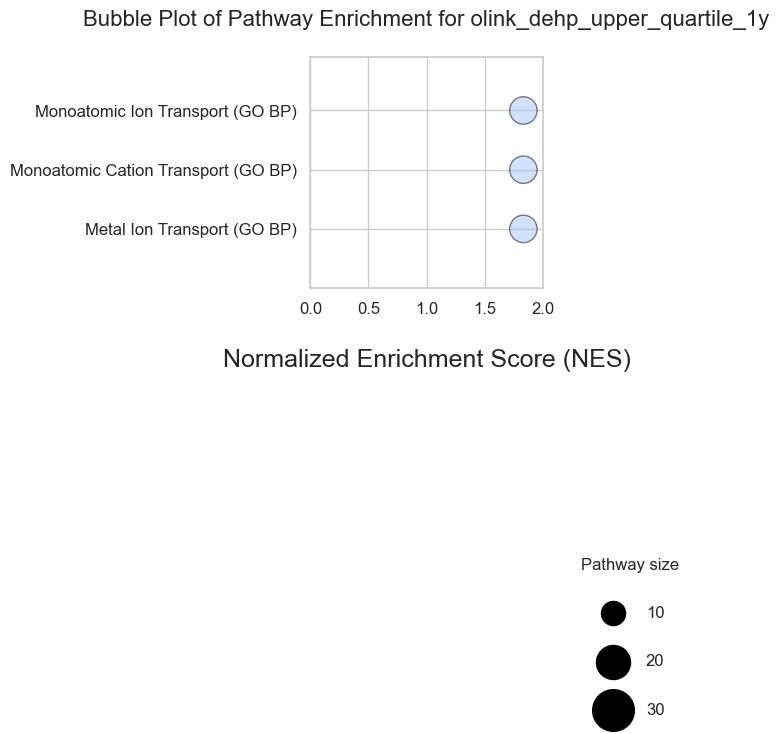

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid")  # Set the style for seaborn plot

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 12,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 12,               # Font size for x-axis tick labels
    'ytick.labelsize': 12,               # Font size for y-axis tick labels
    'legend.fontsize': 12,               # Font size for legend
    'figure.titlesize': 18                # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_dehp_upper_quartile_1y)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

 #Assuming 'setSize' is a column in your DataFrame
# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(3, 3))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 30,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar


# Add labels and title
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=18)
ax.set_ylabel('', fontsize=10)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_dehp_upper_quartile_1y\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 20, 30]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 30, c='black',  edgecolor='black', label=f'{size}')  # Keep size same

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(title='Pathway size', loc='upper left', bbox_to_anchor=(1.1, -1.1), 
                title_fontsize=12, frameon=False, handletextpad=1,labelspacing=2)  # Increased handletextpad
# Set x-axis limits
ax.set_xlim(0, 2)  # Set x-axis limits
# Display plot
ax.set_ylim(-1, len(df) - 0.1)
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the colorbar
plt.show()

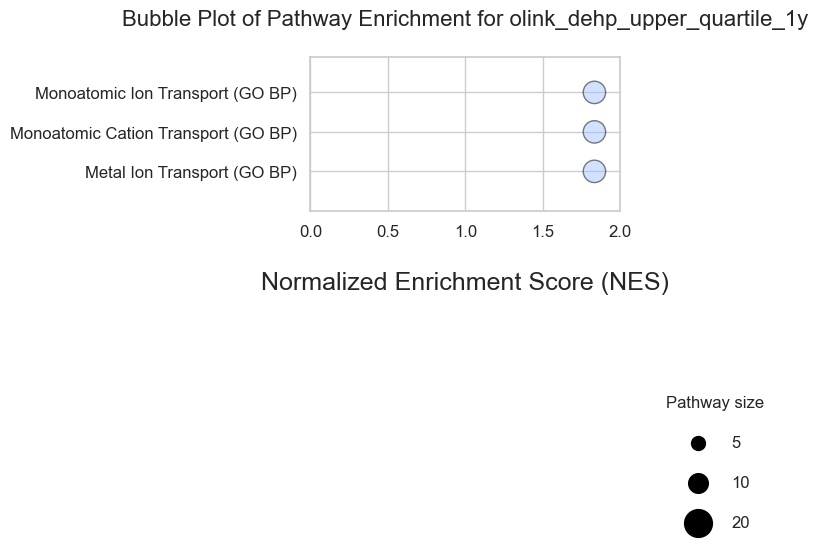

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 12,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 12,               # Font size for x-axis tick labels
    'ytick.labelsize': 12,               # Font size for y-axis tick labels
    'legend.fontsize': 12,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_dehp_upper_quartile_1y)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(4, 2))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 20,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
#for i, row in df.iterrows():
#    ax.text(
#        row['NES']-0.05, i, row['core_enrichment'],  # i is used for y-coordinate
#        va='center', ha='right', fontsize=11, color='black'
#    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Add labels and title
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=18)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_dehp_upper_quartile_1y\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [5, 10, 20]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 20, c='black', edgecolor='black', label=f'{size}')  # Keep size same

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(title='Pathway size', loc='upper left', bbox_to_anchor=(1.1, -1.1), 
                title_fontsize=12, frameon=False, handletextpad=1, labelspacing=1.5)  # Increased handletextpad

# Set x-axis limits
ax.set_xlim(0, 2)  # Set x-axis limits
ax.set_ylim(-1, len(df) - 0.1)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


# Table 1 - entry for DEHP and leading edge 1-year cytokines from GSEA

In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_result_dehp_1y_gsea.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_dehp_upper_quartile_1y['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_dehp_upper_quartile_1y)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=False
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 3 pathways):
----------------------------------------------------------------------
CCL8                           3/3 (100.0%)  change: 0.230
CXCL10                         3/3 (100.0%)  change: 0.237
CCL19                          3/3 (100.0%)  change: 0.251
CCL4                           3/3 (100.0%)  change: 0.297
IFNG                           3/3 (100.0%)  change: 0.338
CCL3                           3/3 (100.0%)  change: 0.683


CCL8, CXCL10, CCL19, CCL4, IFNG, CCL3, 

In [ ]:
for chemokine in ordered_list:
    print(chemokine, end=", ")

CCL8, CXCL10, CCL19, CCL4, IFNG, CCL3, 

# Supplementary figure 12d: 5-year pathways and DEHP being in the upper quartile

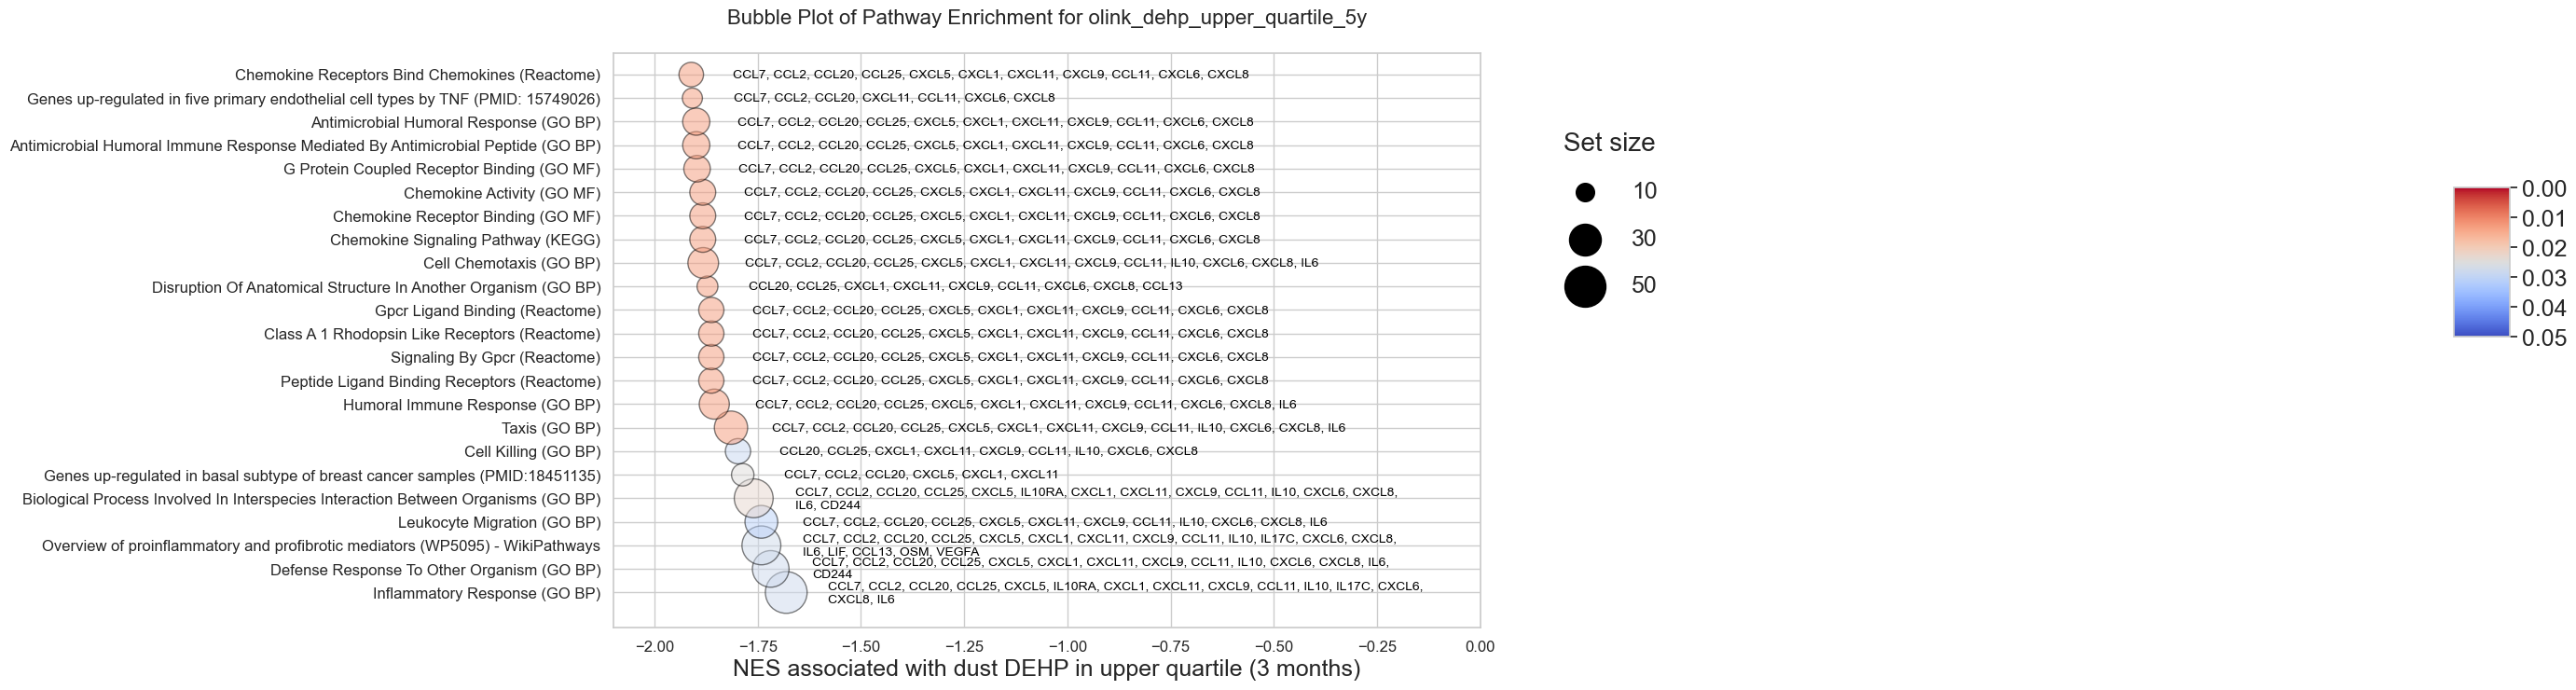

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 8,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 12,               # Font size for x-axis tick labels
    'ytick.labelsize': 12,               # Font size for y-axis tick labels
    'legend.fontsize': 8,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_dehp_upper_quartile_5y)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] *20,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    core_text = row['core_enrichment']
    
    # Wrap text if it's longer than 90 characters
    if len(core_text) > 60:
        core_text = '\n'.join(textwrap.wrap(core_text, 90))
    
    ax.text(
        row['NES'] + 0.1,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        core_text,  # Display comma-delimited core enrichment genes
        va='center', ha='left', fontsize=10, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Manually set the position of the colorbar
cbar_ax = fig.add_axes([1.77, 0.5, 0.05, 0.2])  # Adjust these values for position and size
cbar = fig.colorbar(sm, cax=cbar_ax)  # Use the new axes for the colorbar

# Set colorbar ticks
cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # Set colorbar ticks
cbar.ax.invert_yaxis()  # Invert so that red is at the top and blue is at the bottom

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=18)

# Set horizontal colorbar label below the colorbar
cbar.ax.set_xlabel('', fontsize=5)
cbar.ax.xaxis.set_label_position('top')  # Set the position of the label
cbar.ax.xaxis.labelpad = 3  # Adjust the padding to create space between colorbar and label

# Add labels and title
ax.set_xlabel('NES associated with dust DEHP in upper quartile (3 months)', fontsize=18)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_dehp_upper_quartile_5y\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 30, 50]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 20, c='black', edgecolor='black', label=f'{size}')

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Set size', loc='upper left', bbox_to_anchor=(1.07, 0.90), 
    title_fontsize=20, fontsize=18, frameon=False, handletextpad=1, labelspacing=1.1
)

# Set x-axis limits
ax.set_xlim(-2.1, 0)  # Set x-axis limits
ax.set_ylim(-1.5, len(df) - 0.1)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
#plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


In [ ]:
olink_1y_and_5y_dehp_upper_quartile.sort_values(by="p.adjust")

,Unnamed: 0,exposure,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,visit
25,REACTOME_CHEMOKINE_RECEPTORS_BIND_CHEMOKINES,Dust DEHP in upper quartile,REACTOME_CHEMOKINE_RECEPTORS_BIND_CHEMOKINES,Chemokine Receptors Bind Chemokines (Reactome),18,0.764544,-1.910906,0.000152,0.012559,0.011162,14,"tags=61%, list=15%, signal=64%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL1, CXCL11...",5 Years
23,GOBP_ANTIMICROBIAL_HUMORAL_RESPONSE,Dust DEHP in upper quartile,GOBP_ANTIMICROBIAL_HUMORAL_RESPONSE,Antimicrobial Humoral Response (GO BP),22,0.729276,-1.898783,0.000115,0.012559,0.011162,14,"tags=50%, list=15%, signal=56%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL1, CXCL11...",5 Years
22,GOBP_ANTIMICROBIAL_HUMORAL_IMMUNE_RESPONSE_MED...,Dust DEHP in upper quartile,GOBP_ANTIMICROBIAL_HUMORAL_IMMUNE_RESPONSE_MED...,Antimicrobial Humoral Immune Response Mediated...,22,0.729276,-1.898783,0.000115,0.012559,0.011162,14,"tags=50%, list=15%, signal=56%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL1, CXCL11...",5 Years
21,GOMF_G_PROTEIN_COUPLED_RECEPTOR_BINDING,Dust DEHP in upper quartile,GOMF_G_PROTEIN_COUPLED_RECEPTOR_BINDING,G Protein Coupled Receptor Binding (GO MF),21,0.736286,-1.896837,0.000250,0.012559,0.011162,14,"tags=52%, list=15%, signal=58%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL1, CXCL11...",5 Years
20,GOMF_CHEMOKINE_ACTIVITY,Dust DEHP in upper quartile,GOMF_CHEMOKINE_ACTIVITY,Chemokine Activity (GO MF),20,0.737511,-1.883022,0.000326,0.012559,0.011162,14,"tags=55%, list=15%, signal=60%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL1, CXCL11...",5 Years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,GOBP_CELL_KILLING,Dust DEHP in upper quartile,GOBP_CELL_KILLING,Cell Killing (GO BP),19,0.714213,-1.797703,0.001495,0.028814,0.025609,14,"tags=47%, list=15%, signal=51%","CCL20, CCL25, CXCL1, CXCL11, CXCL9, CCL11, IL1...",5 Years
6,GOBP_LEUKOCYTE_MIGRATION,Dust DEHP in upper quartile,GOBP_LEUKOCYTE_MIGRATION,Leukocyte Migration (GO BP),32,0.634684,-1.741089,0.001695,0.031248,0.027773,15,"tags=38%, list=16%, signal=48%","CCL7, CCL2, CCL20, CCL25, CXCL5, CXCL11, CXCL9...",5 Years
2,GOBP_MONOATOMIC_ION_TRANSPORT,Dust DEHP in upper quartile,GOBP_MONOATOMIC_ION_TRANSPORT,Monoatomic Ion Transport (GO BP),13,-0.835761,1.833009,0.000240,0.033908,0.030557,10,"tags=46%, list=11%, signal=48%","CCL8, CXCL10, CCL19, CCL4, IFNG, CCL3",1 Year
1,GOBP_MONOATOMIC_CATION_TRANSPORT,Dust DEHP in upper quartile,GOBP_MONOATOMIC_CATION_TRANSPORT,Monoatomic Cation Transport (GO BP),13,-0.835761,1.833009,0.000240,0.033908,0.030557,10,"tags=46%, list=11%, signal=48%","CCL8, CXCL10, CCL19, CCL4, IFNG, CCL3",1 Year


# Table 1 - entry for DEHP and leading edge 5-year cytokines from GSEA

In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_result_dehp_5y_gsea.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_dehp_upper_quartile_5y['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_dehp_upper_quartile_5y)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=True
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 23 pathways):
----------------------------------------------------------------------
CXCL8                          22/23 (95.7%)  change: -0.140
CXCL6                          22/23 (95.7%)  change: -0.144
CCL11                          22/23 (95.7%)  change: -0.158
CXCL9                          21/23 (91.3%)  change: -0.172
CXCL11                         23/23 (100.0%)  change: -0.182
CXCL1                          21/23 (91.3%)  change: -0.198
CXCL5                          20/23 (87.0%)  change: -0.217
CCL25                          21/23 (91.3%)  change: -0.255
CCL20                          23/23 (100.0%)  change: -0.257
CCL2                           21/23 (91.3%)  change: -0.296
CCL7                           21/23 (91.3%)  change: -0.634


CXCL8, CXCL6, CCL11, CXCL9, CXCL11, CXCL1, CXCL5, CCL25, CCL20, CCL2, CCL7, 

In [ ]:
for chemokine in ordered_list:
    print(chemokine, end=", ")

CXCL8, CXCL6, CCL11, CXCL9, CXCL11, CXCL1, CXCL5, CCL25, CCL20, CCL2, CCL7, 

# Supplementary figure 9a: Weekly chemical hand cleaner use by mother prenatal

In [ ]:
olink_1y_weekly_chemical_hand_cleaner_used_prenatal = pd.read_csv("olink_1y_weekly_chem_hand_cleaner_use_mother_prenatal.csv")
olink_1y_weekly_chemical_hand_cleaner_used_prenatal['visit']='1 Year'
# Invert the NES to indicate change relative to the no exposure
olink_1y_weekly_chemical_hand_cleaner_used_prenatal['NES'] = olink_1y_weekly_chemical_hand_cleaner_used_prenatal['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_1y_weekly_chemical_hand_cleaner_used_prenatal['Description'] = olink_1y_weekly_chemical_hand_cleaner_used_prenatal['Description'].apply(clean_description)
olink_1y_weekly_chemical_hand_cleaner_used_prenatal.sort_values(by="NES",inplace=True, ascending=False)

olink_1y_weekly_chemical_hand_cleaner_used_prenatal.reset_index(drop=True, inplace=True)


for index, row in olink_1y_weekly_chemical_hand_cleaner_used_prenatal.iterrows():
    olink_1y_weekly_chemical_hand_cleaner_used_prenatal.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

olink_1y_weekly_chemical_hand_cleaner_used_prenatal['Description'].replace("KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY","Toll-like receptor signaling pathway (KEGG:hsa04620)",inplace=True)
olink_1y_weekly_chemical_hand_cleaner_used_prenatal['Description'].replace("WP_TOLLLIKE_RECEPTOR_SIGNALING_PATHWAY","Toll-like receptor signaling pathway (WikiPathways:WP75)",inplace=True)
olink_1y_weekly_chemical_hand_cleaner_used_prenatal['Description'].replace("BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECTION_A594_CELLS_UP","Genes upregulated in A549 lung alveolar cells due to HPIV3 (PMID:32416070)",inplace=True)



0          Toll Like Receptor Signaling Pathway (KEGG)
1                       WP_TOLLLIKE_RECEPTOR_SIGNALING
2    Genes upregulated in A549 lung alveolar cells ...
Name: Description, dtype: str

In [ ]:
olink_1y_weekly_chemical_hand_cleaner_used_prenatal

,Unnamed: 0,exposure,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,visit
0,KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY,Weekly chemical hand cleaner used by mother (p...,KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY,Toll Like Receptor Signaling Pathway (KEGG),11,-0.876836,1.841721,0.000058,0.012324,0.010617,14,"tags=73%, list=15%, signal=70%","TNF, CXCL8, CXCL9, CXCL10, CXCL11, CCL4, IL6, ...",1 Year
1,WP_TOLLLIKE_RECEPTOR_SIGNALING,Weekly chemical hand cleaner used by mother (p...,WP_TOLLLIKE_RECEPTOR_SIGNALING,WP_TOLLLIKE_RECEPTOR_SIGNALING,11,-0.876836,1.841721,0.000058,0.012324,0.010617,14,"tags=73%, list=15%, signal=70%","TNF, CXCL8, CXCL9, CXCL10, CXCL11, CCL4, IL6, ...",1 Year
2,BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECT...,Weekly chemical hand cleaner used by mother (p...,BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECT...,BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECT...,10,-0.881287,1.820419,0.000135,0.019127,0.016477,7,"tags=50%, list=8%, signal=52%","CXCL10, CXCL11, CCL4, IL6, CCL3",1 Year


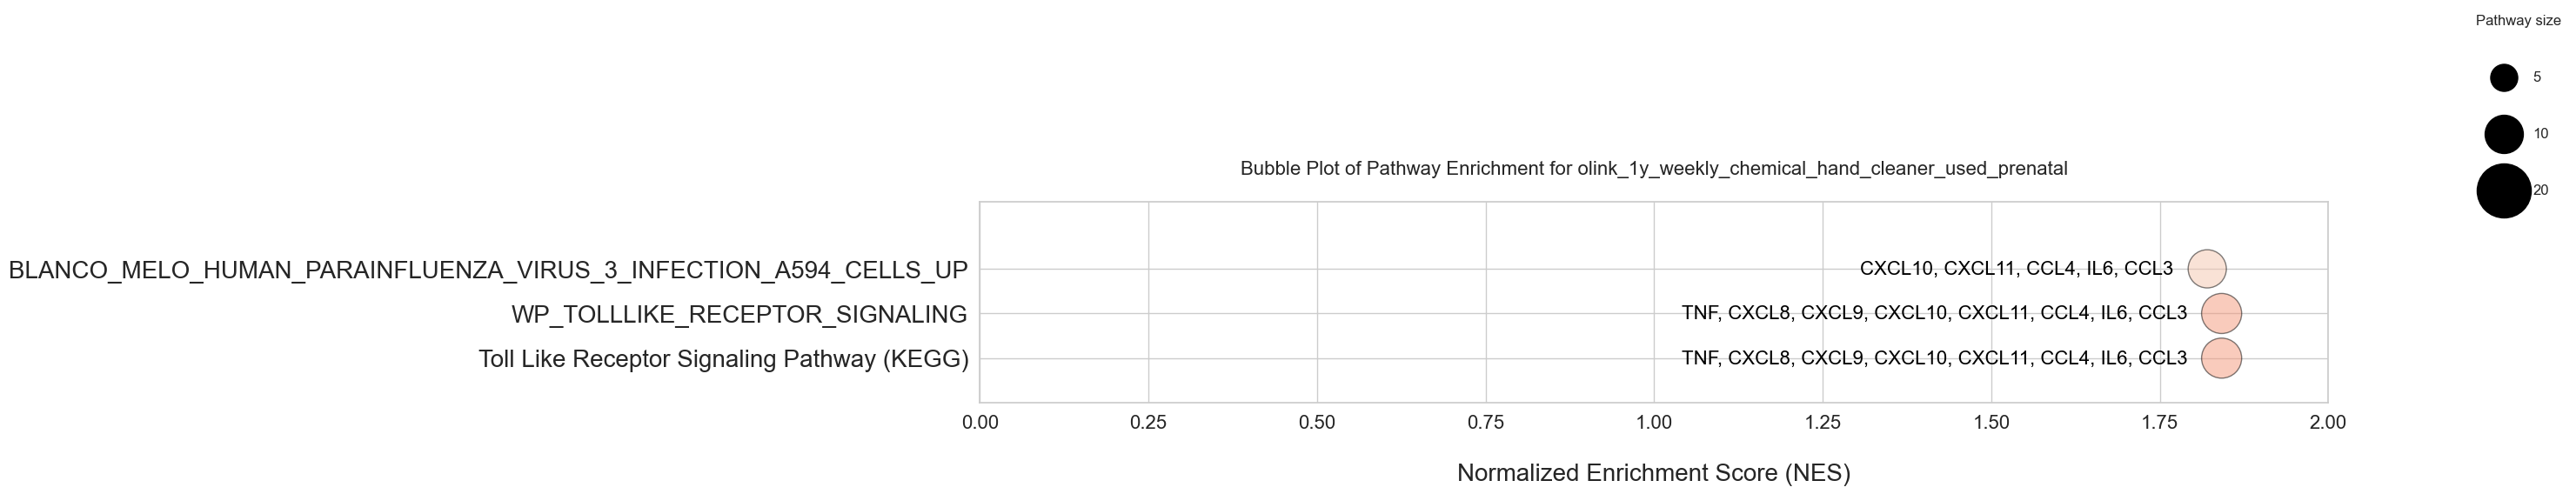

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 14,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 16,               # Font size for x-axis tick labels
    'ytick.labelsize': 20,               # Font size for y-axis tick labels
    'legend.fontsize': 12,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_1y_weekly_chemical_hand_cleaner_used_prenatal)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(20, 3))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 100,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    ax.text(
        row['NES'] - 0.05,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        row['core_enrichment'],  # Display comma-delimited core enrichment genes
        va='center', ha='right', fontsize=16, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Add labels and title
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=20)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_1y_weekly_chemical_hand_cleaner_used_prenatal\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [5, 10, 20]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 100, c='black', edgecolor='black', label=f'{size}')  # Keep size same

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Pathway size', loc='upper left', bbox_to_anchor=(1.1, 2.0), 
    title_fontsize=12, frameon=False, handletextpad=1, labelspacing=3
)

# Set x-axis limits
ax.set_xlim(0, 2)  # Set x-axis limits
ax.set_ylim(-1, len(df) + 0.5)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


# Table 1 - entry for weekly chemical hand cleaner and leading edge 1-year cytokines from GSEA

In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_results_1y_weekly_chemical_hand_cleaner.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_1y_weekly_chemical_hand_cleaner_used_prenatal['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_1y_weekly_chemical_hand_cleaner_used_prenatal)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=False
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")

Chemokines sorted by change (across 3 pathways):
----------------------------------------------------------------------
TNF                            2/3 (66.7%)  change: 0.217
CXCL8                          2/3 (66.7%)  change: 0.269
CXCL9                          2/3 (66.7%)  change: 0.286
CXCL10                         3/3 (100.0%)  change: 0.374
CXCL11                         3/3 (100.0%)  change: 0.380
CCL4                           3/3 (100.0%)  change: 0.516
IL6                            3/3 (100.0%)  change: 0.616
CCL3                           3/3 (100.0%)  change: 1.094


In [ ]:
for chemokine in ordered_list:
    print(chemokine, end=", ")

TNF, CXCL8, CXCL9, CXCL10, CXCL11, CCL4, IL6, CCL3, 

# Supplementary Figure 8c: Daily hand sanitizer used by mother (prenatal)
Pathways were only enriched for the 5-year time point

In [ ]:

### NOTE: I'm putting in a flag that will selectively show pathways in order to reduce size of figure for talks

REDUCE_ROWS = 1


olink_5y_daily_hand_sanitizer_used_prenatal = pd.read_csv("olink_5y_prenatal_daily_hand_sanitizer.csv")
olink_5y_daily_hand_sanitizer_used_prenatal['visit']='5 Years'



#olink_5y_daily_hand_sanitizer_used_prenatal = olink_5y_daily_hand_sanitizer_used_prenatal.drop(to_drop)


# Invert the NES to indicate change relative to the no exposure
olink_5y_daily_hand_sanitizer_used_prenatal['NES'] = olink_5y_daily_hand_sanitizer_used_prenatal['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_5y_daily_hand_sanitizer_used_prenatal['Description'] = olink_5y_daily_hand_sanitizer_used_prenatal['Description'].apply(clean_description)
olink_5y_daily_hand_sanitizer_used_prenatal.sort_values(by="NES",inplace=True, ascending=False)

olink_5y_daily_hand_sanitizer_used_prenatal.reset_index(drop=True, inplace=True)

for index, row in olink_5y_daily_hand_sanitizer_used_prenatal.iterrows():
    olink_5y_daily_hand_sanitizer_used_prenatal.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

In [ ]:
olink_5y_daily_hand_sanitizer_used_prenatal = olink_5y_daily_hand_sanitizer_used_prenatal[olink_5y_daily_hand_sanitizer_used_prenatal['Description']!='NABA_SECRETED_FACTORS']
olink_5y_daily_hand_sanitizer_used_prenatal['Description'].replace("SAUL_SEN_MAYO","Senescence-associated secretory phenotype (PMID:35974106)",inplace=True)
olink_5y_daily_hand_sanitizer_used_prenatal['Description'].replace("WP_MACROPHAGESTIMULATING_PROTEIN_MSP_SIGNALING","Macrophage-stimulating protein (MSP) signaling",inplace=True)
for index, row in olink_5y_daily_hand_sanitizer_used_prenatal.iterrows():
    if row['Description'].startswith("LINDSTEDT_DENDRITIC_CELL_MATURATION_A"):
        olink_5y_daily_hand_sanitizer_used_prenatal.loc[index,"Description"] = "Maturation of monocyte-derived dendritic cells (PMID:12356685)"
    if row['Description'].startswith("OSWALD_HEMATOPOIETIC_STEM_CELL_IN_COLLAGEN_GEL_UP"):
        olink_5y_daily_hand_sanitizer_used_prenatal.loc[index,"Description"] ="Genes up-regulated in hematopoietic stem cells (PMID:16166251)"
    if row['Description'].startswith("BLANCO_MELO_COVID19_SARS_COV_2_INFECTION_A594_ACE2_EXPRESSING_CELLS_UP"):
        olink_5y_daily_hand_sanitizer_used_prenatal.loc[index,"Description"] = "Genes up-regulated in SARS-CoV-2 infection (PMID:32416070)"
    if row['Description'].startswith("ZHOU_INFLAMMATORY_RESPONSE_LIVE_UP"):
        olink_5y_daily_hand_sanitizer_used_prenatal.loc[index,"Description"] ="Genes up-regulated in macrophage (PMID:18025224)"

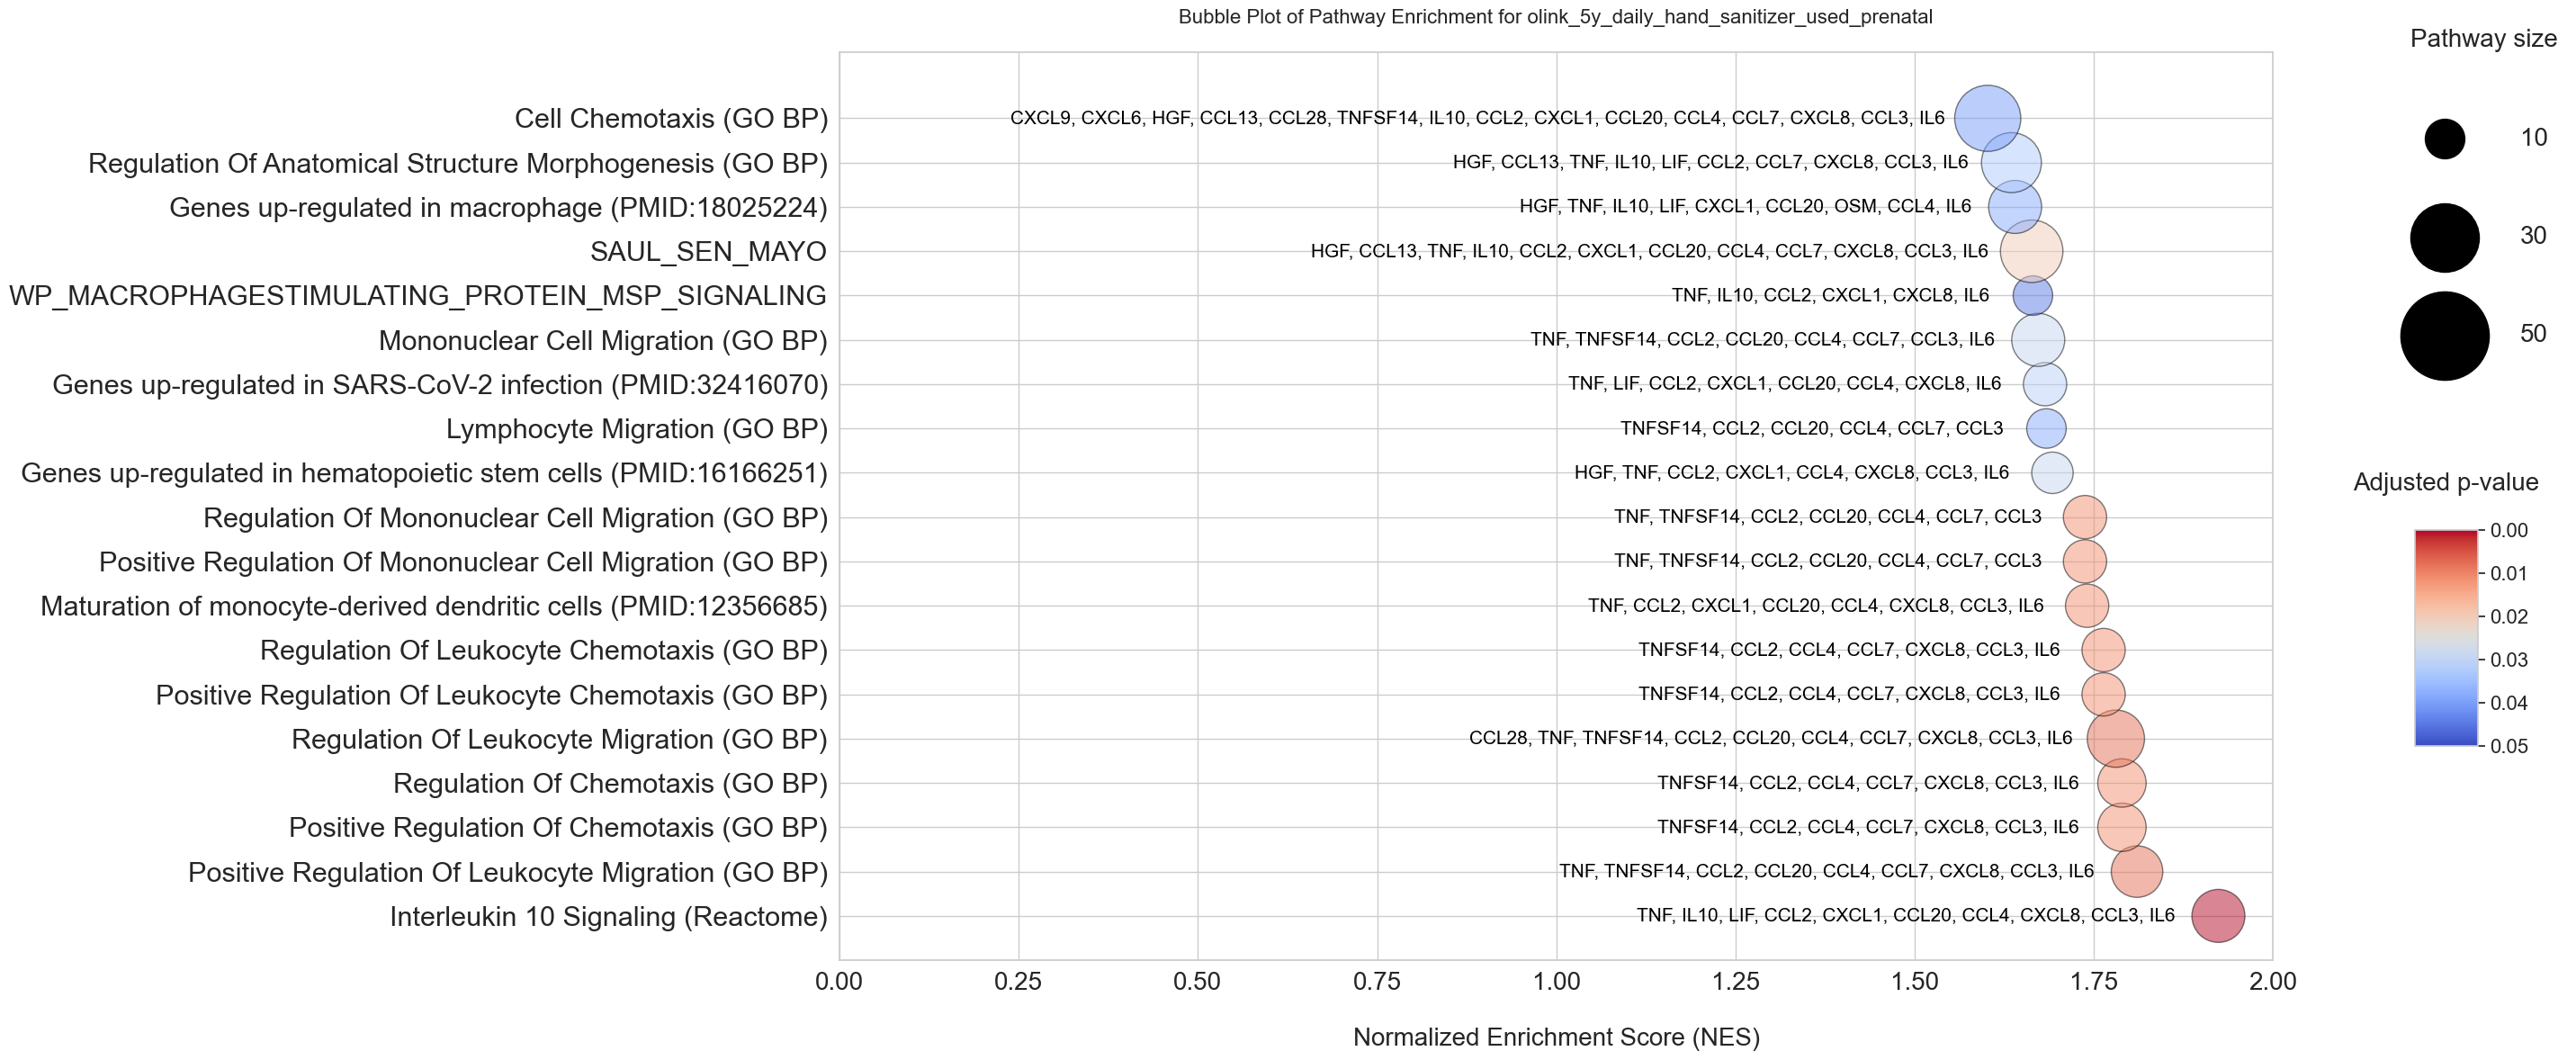

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 14,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 20,               # Font size for x-axis tick labels
    'ytick.labelsize': 22,               # Font size for y-axis tick labels
    'legend.fontsize': 16,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_5y_daily_hand_sanitizer_used_prenatal)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(35, 12))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 100,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    ax.text(
        row['NES'] - 0.06,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        row['core_enrichment'],  # Display comma-delimited core enrichment genes
        va='center', ha='right', fontsize=15, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Manually set the position of the colorbar
cbar_ax = fig.add_axes([0.77, 0.3, 0.02, 0.2])  # Adjust these values for position and size
cbar = fig.colorbar(sm, cax=cbar_ax)  # Use the new axes for the colorbar

# Set colorbar ticks
cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # Set colorbar ticks
cbar.ax.invert_yaxis()  # Invert so that red is at the top and blue is at the bottom

# Set the font size of the colorbar tick labels (smaller size)
cbar.ax.tick_params(labelsize=16)  # Change this number to control the font size

# Set horizontal colorbar label below the colorbar
cbar.ax.set_xlabel('\nAdjusted p-value\n', fontsize=20)
cbar.ax.xaxis.set_label_position('top')  # Set the position of the label
cbar.ax.xaxis.labelpad = 10  # Adjust the padding to create space between colorbar and label

# Add labels and title
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=20)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_5y_daily_hand_sanitizer_used_prenatal\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 30, 50]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 100, c='black', edgecolor='black', label=f'{size}')  # Keep size same

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Pathway size', loc='upper left', bbox_to_anchor=(1.08, 1.05), 
    title_fontsize=20, fontsize=20, frameon=False, handletextpad=2, labelspacing=3
)

# Set x-axis limits
ax.set_xlim(0, 2)  # Set x-axis limits
ax.set_ylim(-1, len(df) + 0.5)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_result_prenatal_daily_hand_sanitizer_5y_gsea.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_5y_daily_hand_sanitizer_used_prenatal['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_5y_daily_hand_sanitizer_used_prenatal)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=False
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")

for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 19 pathways):
----------------------------------------------------------------------
TNF                            13/19 (68.4%)  change: 0.223
TNFSF14                        11/19 (57.9%)  change: 0.253
CCL2                           18/19 (94.7%)  change: 0.286
CCL20                          12/19 (63.2%)  change: 0.354
CCL4                           17/19 (89.5%)  change: 0.364
CCL7                           13/19 (68.4%)  change: 0.453
CXCL8                          14/19 (73.7%)  change: 0.476
CCL3                           16/19 (84.2%)  change: 0.556
IL6                            16/19 (84.2%)  change: 0.598
TNF, TNFSF14, CCL2, CCL20, CCL4, CCL7, CXCL8, CCL3, IL6, 

In [ ]:
for chemokine in ordered_list:
    print(chemokine, end=", ")

TNF, TNFSF14, CCL2, CCL20, CCL4, CCL7, CXCL8, CCL3, IL6, 

# Figure 4c - Associations between 5-year pathways and upper quartile adrenic acid levels


In [ ]:
olink_5y_upper_quartile_adrenic_acid_= pd.read_csv("olink_5y_upper_quartile_adrenic_acid_5y.csv")
olink_5y_upper_quartile_adrenic_acid_['visit']='5 Years'
# Invert the NES to indicate change relative to the no exposure
olink_5y_upper_quartile_adrenic_acid_['NES'] = olink_5y_upper_quartile_adrenic_acid_['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_5y_upper_quartile_adrenic_acid_['Description'] = olink_5y_upper_quartile_adrenic_acid_['Description'].apply(clean_description)
olink_5y_upper_quartile_adrenic_acid_.sort_values(by="NES",inplace=True, ascending=False)

olink_5y_upper_quartile_adrenic_acid_.reset_index(drop=True, inplace=True)


for index, row in olink_5y_upper_quartile_adrenic_acid_.iterrows():
    olink_5y_upper_quartile_adrenic_acid_.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

olink_5y_upper_quartile_adrenic_acid_['Description'].replace("KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY","Toll-like receptor signaling pathway (KEGG:hsa04620)",inplace=True)
olink_5y_upper_quartile_adrenic_acid_['Description'] = olink_5y_upper_quartile_adrenic_acid_['Description'].replace("WP_TOLLLIKE_RECEPTOR_SIGNALING","Toll-like receptor signaling pathway (WikiPathways:WP75)",inplace=True)
olink_5y_upper_quartile_adrenic_acid_['Description'].replace("BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECTION_A594_CELLS_UP","Genes upregulated in A549 lung alveolar cells due to HPIV3 (PMID:32416070)",inplace=True)

for index, row in olink_5y_upper_quartile_adrenic_acid_.iterrows():
    if row['Description'].startswith("LINDSTEDT_DENDRITIC_CELL_MATURATION_A"):
        olink_5y_upper_quartile_adrenic_acid_.loc[index,"Description"] = "Maturation of monocyte-derived dendritic cells (PMID:12356685)"



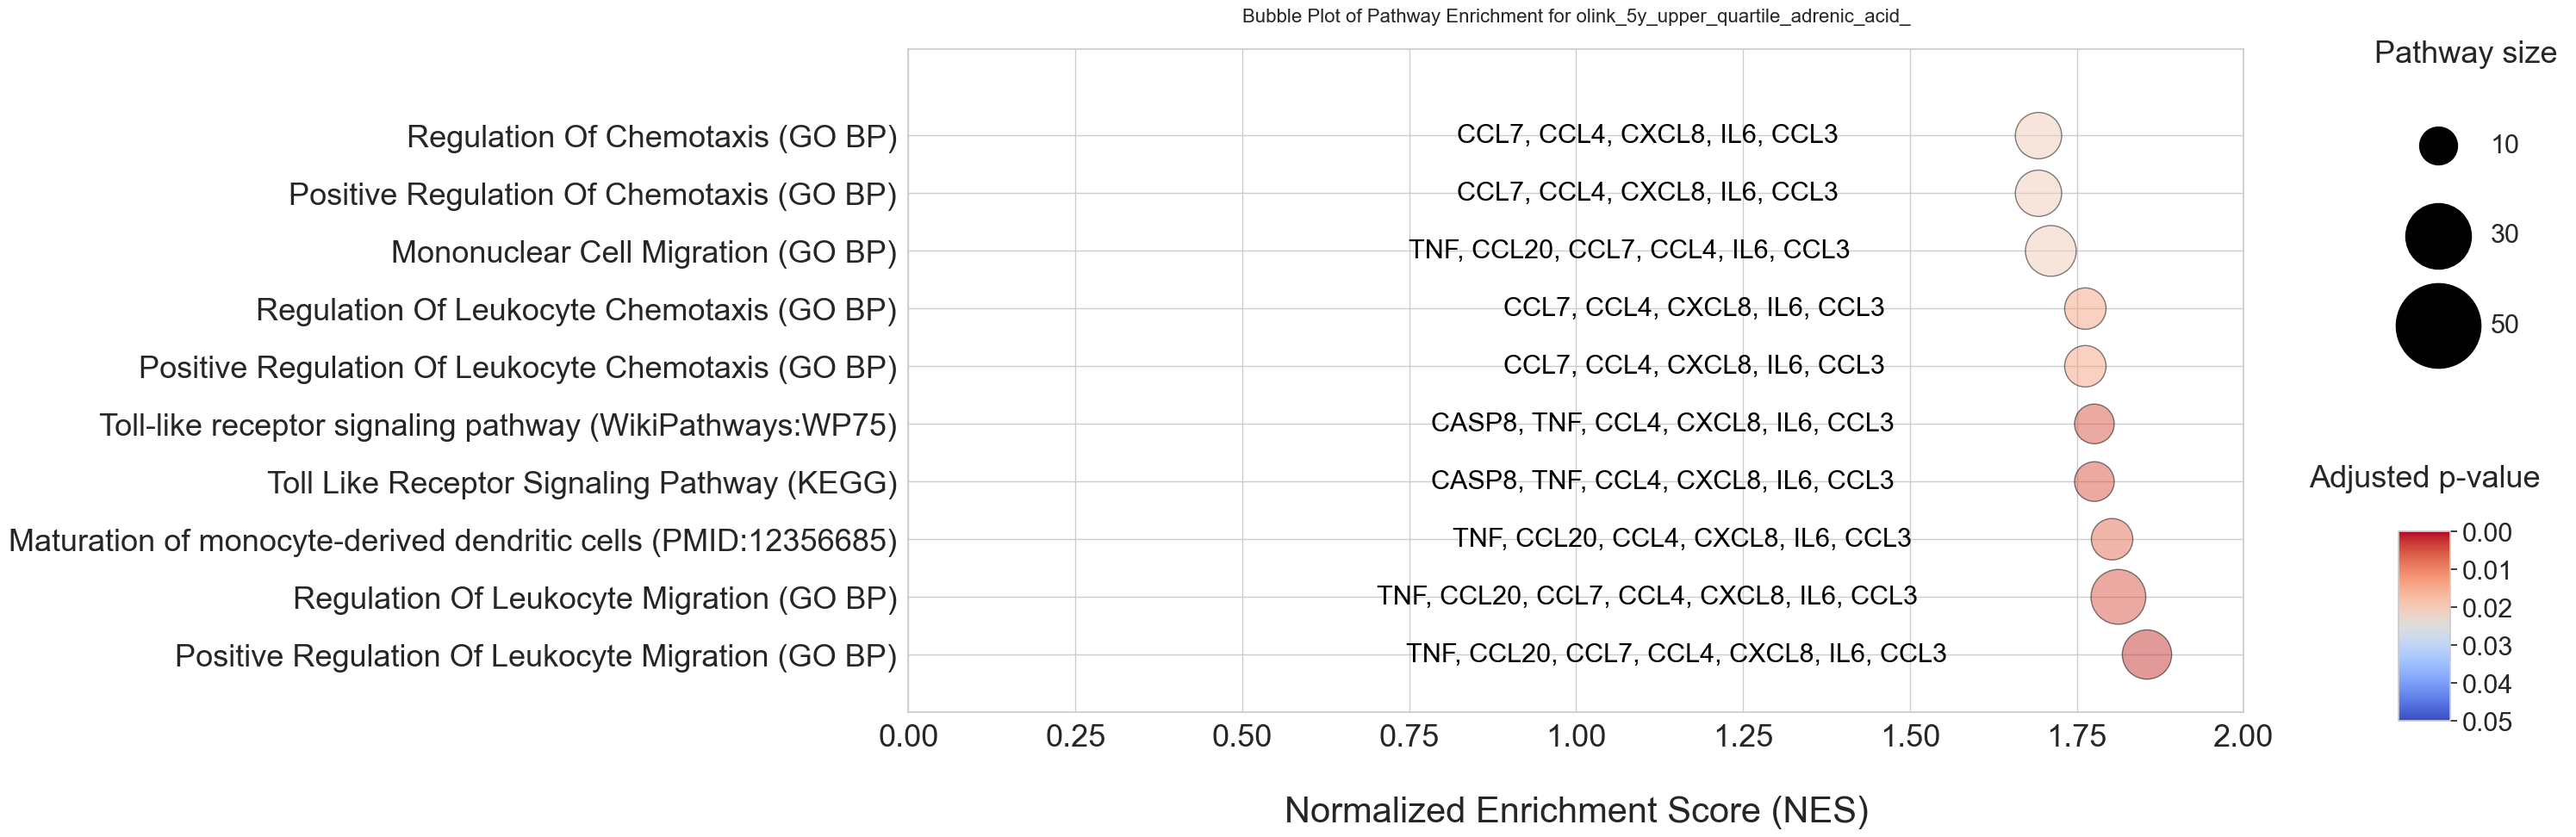

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 22,                     # Default font size
    'axes.titlesize': 26,                # Font size for title
    'axes.labelsize': 26,                # Font size for axis labels
    'xtick.labelsize': 26,               # Font size for x-axis tick labels
    'ytick.labelsize': 26,               # Font size for y-axis tick labels
    'legend.fontsize': 22,               # Font size for legend
    'figure.titlesize': 22               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_5y_upper_quartile_adrenic_acid_)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(20, 10))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 100,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    ax.text(
        row['NES'] - 0.3,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        row['core_enrichment'],  # Display comma-delimited core enrichment genes
        va='center', ha='right', fontsize=22, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Manually set the position of the colorbar
cbar_ax = fig.add_axes([0.99, 0.1, 0.03, 0.22])  # Adjust these values for position and size
cbar = fig.colorbar(sm, cax=cbar_ax)  # Use the new axes for the colorbar

# Set colorbar ticks
cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # Set colorbar ticks
cbar.ax.invert_yaxis()  # Invert so that red is at the top and blue is at the bottom

# Set the font size of the colorbar tick labels (smaller size)
cbar.ax.tick_params(labelsize=22)  # Change this number to control the font size

# Set horizontal colorbar label below the colorbar
cbar.ax.set_xlabel('\nAdjusted p-value\n', fontsize=26)
cbar.ax.xaxis.set_label_position('top')  # Set the position of the label
cbar.ax.xaxis.labelpad = 10  # Adjust the padding to create space between colorbar and label

# Add labels and title
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=30)
ax.set_ylabel('', fontsize=26)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_5y_upper_quartile_adrenic_acid_\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 30, 50]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 100, c='black', edgecolor='black', label=f'{size}')  # Keep size same

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Pathway size', loc='upper left', bbox_to_anchor=(1.08, 1.05), 
    title_fontsize=26, fontsize=22, frameon=False, handletextpad=1, labelspacing=2.5
)

# Set x-axis limits
ax.set_xlim(0,2)  # Set x-axis limits
ax.set_ylim(-1, len(df) + 0.5)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
#plt.tight_layout(rect=[0, 0, 0, 1])

# Display plot
plt.show()


In [ ]:
olink_5y_upper_quartile_adrenic_acid_

,Unnamed: 0,exposure,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,visit
0,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_MIGRATION,Upper quartile adrenic acid,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_MIGRATION,Positive Regulation Of Leukocyte Migration (GO...,17,-0.844253,1.854955,0.000006,0.002611,0.002282,8,"tags=41%, list=9%, signal=46%","TNF, CCL20, CCL7, CCL4, CXCL8, IL6, CCL3",5 Years
1,GOBP_REGULATION_OF_LEUKOCYTE_MIGRATION,Upper quartile adrenic acid,GOBP_REGULATION_OF_LEUKOCYTE_MIGRATION,Regulation Of Leukocyte Migration (GO BP),21,-0.806823,1.812125,0.000030,0.005093,0.004450,8,"tags=33%, list=9%, signal=39%","TNF, CCL20, CCL7, CCL4, CXCL8, IL6, CCL3",5 Years
2,LINDSTEDT_DENDRITIC_CELL_MATURATION_A,Upper quartile adrenic acid,LINDSTEDT_DENDRITIC_CELL_MATURATION_A,Maturation of monocyte-derived dendritic cells...,12,-0.863411,1.802678,0.000091,0.007757,0.006779,8,"tags=50%, list=9%, signal=52%","TNF, CCL20, CCL4, CXCL8, IL6, CCL3",5 Years
3,KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY,Upper quartile adrenic acid,KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY,Toll Like Receptor Signaling Pathway (KEGG),11,-0.866275,1.776173,0.000048,0.005093,0.004450,11,"tags=55%, list=12%, signal=55%","CASP8, TNF, CCL4, CXCL8, IL6, CCL3",5 Years
4,WP_TOLLLIKE_RECEPTOR_SIGNALING,Upper quartile adrenic acid,WP_TOLLLIKE_RECEPTOR_SIGNALING,WP_TOLLLIKE_RECEPTOR_SIGNALING,11,-0.866275,1.776173,0.000048,0.005093,0.004450,11,"tags=55%, list=12%, signal=55%","CASP8, TNF, CCL4, CXCL8, IL6, CCL3",5 Years
5,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_CHEMOTAXIS,Upper quartile adrenic acid,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_CHEMOTAXIS,Positive Regulation Of Leukocyte Chemotaxis (G...,12,-0.844229,1.762628,0.000228,0.013791,0.012052,6,"tags=42%, list=7%, signal=45%","CCL7, CCL4, CXCL8, IL6, CCL3",5 Years
6,GOBP_REGULATION_OF_LEUKOCYTE_CHEMOTAXIS,Upper quartile adrenic acid,GOBP_REGULATION_OF_LEUKOCYTE_CHEMOTAXIS,Regulation Of Leukocyte Chemotaxis (GO BP),12,-0.844229,1.762628,0.000228,0.013791,0.012052,6,"tags=42%, list=7%, signal=45%","CCL7, CCL4, CXCL8, IL6, CCL3",5 Years
7,GOBP_MONONUCLEAR_CELL_MIGRATION,Upper quartile adrenic acid,GOBP_MONONUCLEAR_CELL_MIGRATION,Mononuclear Cell Migration (GO BP),18,-0.775110,1.710975,0.000401,0.020577,0.017982,8,"tags=33%, list=9%, signal=38%","TNF, CCL20, CCL7, CCL4, IL6, CCL3",5 Years
8,GOBP_POSITIVE_REGULATION_OF_CHEMOTAXIS,Upper quartile adrenic acid,GOBP_POSITIVE_REGULATION_OF_CHEMOTAXIS,Positive Regulation Of Chemotaxis (GO BP),15,-0.783821,1.692489,0.000485,0.020577,0.017982,6,"tags=33%, list=7%, signal=37%","CCL7, CCL4, CXCL8, IL6, CCL3",5 Years
9,GOBP_REGULATION_OF_CHEMOTAXIS,Upper quartile adrenic acid,GOBP_REGULATION_OF_CHEMOTAXIS,Regulation Of Chemotaxis (GO BP),15,-0.783821,1.692489,0.000485,0.020577,0.017982,6,"tags=33%, list=7%, signal=37%","CCL7, CCL4, CXCL8, IL6, CCL3",5 Years


# Table 1 entry for upper quartile adrenic acid use

In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_results_monthly_upper_quartile_adrenic_acid_5y.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_5y_upper_quartile_adrenic_acid_['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_5y_upper_quartile_adrenic_acid_)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=False
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 10 pathways):
----------------------------------------------------------------------
TNF                            6/10 (60.0%)  change: 0.388
CCL7                           7/10 (70.0%)  change: 0.455
CCL4                           10/10 (100.0%)  change: 0.457
CXCL8                          9/10 (90.0%)  change: 0.548
IL6                            10/10 (100.0%)  change: 0.650
CCL3                           10/10 (100.0%)  change: 0.753


TNF, CCL7, CCL4, CXCL8, IL6, CCL3, 

In order to select chemokines that are representative of any putative asthma endotype, get a list of fold change based on t-test results (contained in cytokine_file below).

Then read the GSEA results. Get all unique core_enrichment cytokines and list what percentage of pathways they are found in. 

Sort by the largest change to the smallest change

Currently going to report those chemokines that are found in at least 50% of the pathways.

In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_results_5y_systemic_ab_eq_2.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_5y_systemic_ab_gte2['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_5y_systemic_ab_gte2)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=True
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 32 pathways):
----------------------------------------------------------------------
CXCL10                         16/32 (50.0%)  change: -0.193
TNF                            17/32 (53.1%)  change: -0.211
IL10                           16/32 (50.0%)  change: -0.235
CXCL9                          27/32 (84.4%)  change: -0.278
CCL4                           27/32 (84.4%)  change: -0.278
CCL2                           30/32 (93.8%)  change: -0.306
IL17A                          16/32 (50.0%)  change: -0.339
CXCL1                          29/32 (90.6%)  change: -0.348
CXCL6                          27/32 (84.4%)  change: -0.350
CXCL5                          29/32 (90.6%)  change: -0.393
CXCL11                         27/32 (84.4%)  change: -0.405
CCL3                           29/32 (90.6%)  change: -0.489
CCL7                           24/32 (75.0%)  change: -0.558
IL6                            20/32 (62.5%)  change: -0.596
CCL20                    

# Supplementary figure 15 and Table 1 entry -  5-year pathways and use of 2 OR MORE systemic antibiotic courses between birth and 1 year of age 

In [ ]:
olink_5y_systemic_ab_gte2 = pd.read_csv("olink_gsea_5y_systemic_ab_gte2_results.csv")
olink_5y_systemic_ab_gte2['visit']='5 Years'
# Invert the NES to indicate change relative to the no exposure
olink_5y_systemic_ab_gte2['NES'] = olink_5y_systemic_ab_gte2['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].apply(clean_description)
olink_5y_systemic_ab_gte2.sort_values(by="NES",inplace=True, ascending=False)

olink_5y_systemic_ab_gte2.reset_index(drop=True, inplace=True)

for index, row in olink_5y_systemic_ab_gte2.iterrows():
    olink_5y_systemic_ab_gte2.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_OVERVIEW_OF_PROINFLAMMATORY_AND_PROFIBROTIC_MEDIATORS","Proinflammatory and profibrotic mediators (WikiPathways:WP5095)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_NETWORK_MAP_OF_SARSCOV2_SIGNALING"," SARS-CoV-2 signaling (WikiPathways:WP5115)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("GAURNIER_PSMD4_TARGETS","Cytokines and their cognate receptors up-regulated in THP-1 cells (monocyte) after treatment with PSMD4 (PMID:18632645)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("SANA_TNF_SIGNALING_UP","Genes up-regulated in five primary endothelial cell types (lung, aortic, iliac, dermal, and colon) by TNF(PMID:15749026)",inplace=True)


olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("LINDSTEDT_DENDRITIC_CELL_MATURATION_A","Maturation of monocyte-derived dendritic cells (DC) in response to inflammatory stimuli: (PMID:12356685)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("MCLACHLAN_DENTAL_CARIES_UP","Genes up-regulated in pulpal tissue extracted from carious teeth (PMID:15869869)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("SMID_BREAST_CANCER_BASAL_UP","Genes up-regulated in basal subtype of breast cancer samles. (PMID:18451135)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECTION_A594_CELLS_UP","Genes up-regulated in response to HPIV3 (A549 cells): (PMID:32416070)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_SARSCOV2_INNATE_IMMUNITY_EVASION_AND_CELLSPECIFIC_IMMUNE_RESPONSE","SARS-CoV-2 innate immunity evasion and cell-specific immune response (WikiPathways:WP5039)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_CHEMOKINE_SIGNALING","Chemokine signaling (WikiPathways:WP3929)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("CHICAS_RB1_TARGETS_SENESCENT","Genes up-regulated in senescent IMR90 cells after knockdown of RB1 (PMID: 20385362)",inplace=True)


In [ ]:
olink_5y_systemic_ab_gte2

,Unnamed: 0,exposure,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,visit
0,GOBP_DEFENSE_RESPONSE_TO_SYMBIONT,Two or more systemic antibiotics given (birth-3m),GOBP_DEFENSE_RESPONSE_TO_SYMBIONT,Defense Response To Symbiont (GO BP),36,0.653145,-1.580275,0.001517,0.041151,0.035961,32,"tags=58%, list=35%, signal=62%","CCL20, CCL7, CCL3, CXCL5, CXCL1, TSLP, CXCL6, ...",5 Years
1,SMID_BREAST_CANCER_BASAL_UP,Two or more systemic antibiotics given (birth-3m),SMID_BREAST_CANCER_BASAL_UP,Genes up-regulated in basal subtype of breast ...,15,0.719178,-1.584532,0.002569,0.047351,0.041379,13,"tags=47%, list=14%, signal=48%","CCL20, CCL7, MMP1, CXCL5, CXCL1, CXCL8, CXCL11",5 Years
2,GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM,Two or more systemic antibiotics given (birth-3m),GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM,Defense Response To Other Organism (GO BP),40,0.655126,-1.587383,0.001435,0.041151,0.035961,32,"tags=55%, list=35%, signal=63%","CCL20, IL6, CCL7, CCL3, CXCL5, CXCL1, TSLP, CX...",5 Years
3,WP_OVERVIEW_OF_PROINFLAMMATORY_AND_PROFIBROTIC...,Two or more systemic antibiotics given (birth-3m),WP_OVERVIEW_OF_PROINFLAMMATORY_AND_PROFIBROTIC...,Proinflammatory and profibrotic mediators (Wik...,45,0.648798,-1.588888,0.002436,0.046940,0.041020,20,"tags=38%, list=22%, signal=58%","CCL20, IL6, CCL7, MMP1, CCL3, CXCL5, CXCL1, TS...",5 Years
4,WP_SARSCOV2_INNATE_IMMUNITY_EVASION_AND_CELLSP...,Two or more systemic antibiotics given (birth-3m),WP_SARSCOV2_INNATE_IMMUNITY_EVASION_AND_CELLSP...,SARS-CoV-2 innate immunity evasion and cell-sp...,15,0.725453,-1.598359,0.001952,0.041151,0.035961,13,"tags=53%, list=14%, signal=55%","IL6, CCL3, CXCL5, CXCL1, CXCL6, CCL4, CXCL8, C...",5 Years
5,KEGG_CHEMOKINE_SIGNALING_PATHWAY,Two or more systemic antibiotics given (birth-3m),KEGG_CHEMOKINE_SIGNALING_PATHWAY,Chemokine Signaling Pathway (KEGG),20,0.695462,-1.598406,0.002038,0.041151,0.035961,13,"tags=45%, list=14%, signal=49%","CCL20, CCL7, CCL3, CXCL5, CXCL1, CXCL6, CCL4, ...",5 Years
6,GOMF_CHEMOKINE_RECEPTOR_BINDING,Two or more systemic antibiotics given (birth-3m),GOMF_CHEMOKINE_RECEPTOR_BINDING,Chemokine Receptor Binding (GO MF),20,0.695462,-1.598406,0.002038,0.041151,0.035961,13,"tags=45%, list=14%, signal=49%","CCL20, CCL7, CCL3, CXCL5, CXCL1, CXCL6, CCL4, ...",5 Years
7,GOMF_CHEMOKINE_ACTIVITY,Two or more systemic antibiotics given (birth-3m),GOMF_CHEMOKINE_ACTIVITY,Chemokine Activity (GO MF),20,0.695462,-1.598406,0.002038,0.041151,0.035961,13,"tags=45%, list=14%, signal=49%","CCL20, CCL7, CCL3, CXCL5, CXCL1, CXCL6, CCL4, ...",5 Years
8,GOMF_G_PROTEIN_COUPLED_RECEPTOR_BINDING,Two or more systemic antibiotics given (birth-3m),GOMF_G_PROTEIN_COUPLED_RECEPTOR_BINDING,G Protein Coupled Receptor Binding (GO MF),21,0.686477,-1.599826,0.002744,0.048478,0.042364,13,"tags=43%, list=14%, signal=48%","CCL20, CCL7, CCL3, CXCL5, CXCL1, CXCL6, CCL4, ...",5 Years
9,BLANCO_MELO_RESPIRATORY_SYNCYTIAL_VIRUS_INFECT...,Two or more systemic antibiotics given (birth-3m),BLANCO_MELO_RESPIRATORY_SYNCYTIAL_VIRUS_INFECT...,BLANCO_MELO_RESPIRATORY_SYNCYTIAL_VIRUS_INFECT...,19,0.709329,-1.622428,0.001920,0.041151,0.035961,19,"tags=47%, list=21%, signal=47%","IL6, MMP1, CCL3, CXCL1, CCL4, CXCL8, CXCL11, T...",5 Years


In [ ]:
ttest_results_5y_systemic_ab_gte2 = pd.read_csv("ttest_results_5y_systemic_ab_gte2.csv")

ttest_results_5y_systemic_ab_gte2[ttest_results_5y_systemic_ab_gte2['Threshold']=='Significant']

,Unnamed: 0,Assay,OlinkID,UniProt,Panel,estimate,0,1,statistic,p.value,parameter,conf.low,conf.high,method,alternative,Adjusted_pval,Threshold
0,1,CD244,OID00477,Q9BZW8,Olink Inflammation,0.186812,5.970405,5.783593,3.859741,0.000513,32.317299,0.088262,0.285362,Welch Two Sample t-test,two.sided,0.044556,Significant
1,2,IL6,OID00482,P05231,Olink Inflammation,0.637733,2.364085,1.726352,3.492884,0.001030,48.485975,0.270725,1.004740,Welch Two Sample t-test,two.sided,0.044556,Significant
2,3,TSLP,OID00497,Q969D9,Olink Inflammation,0.314617,1.843453,1.528836,3.468640,0.001761,27.159092,0.128560,0.500674,Welch Two Sample t-test,two.sided,0.044556,Significant
3,4,CXCL1,OID00496,P09341,Olink Inflammation,0.326575,10.611750,10.285175,3.381035,0.001937,31.601044,0.129729,0.523420,Welch Two Sample t-test,two.sided,0.044556,Significant


In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_results_5y_systemic_ab_gte2.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_5y_systemic_ab_gte2['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_5y_systemic_ab_gte2)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=True
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 24 pathways):
----------------------------------------------------------------------
CXCL6                          19/24 (79.2%)  change: -0.290
CXCL1                          23/24 (95.8%)  change: -0.327
CXCL11                         21/24 (87.5%)  change: -0.350
CXCL5                          22/24 (91.7%)  change: -0.358
CCL4                           19/24 (79.2%)  change: -0.360
CCL3                           20/24 (83.3%)  change: -0.449
CCL20                          20/24 (83.3%)  change: -0.451
CXCL8                          22/24 (91.7%)  change: -0.572
CCL7                           18/24 (75.0%)  change: -0.620


CXCL6, CXCL1, CXCL11, CXCL5, CCL4, CCL3, CCL20, CXCL8, CCL7, 

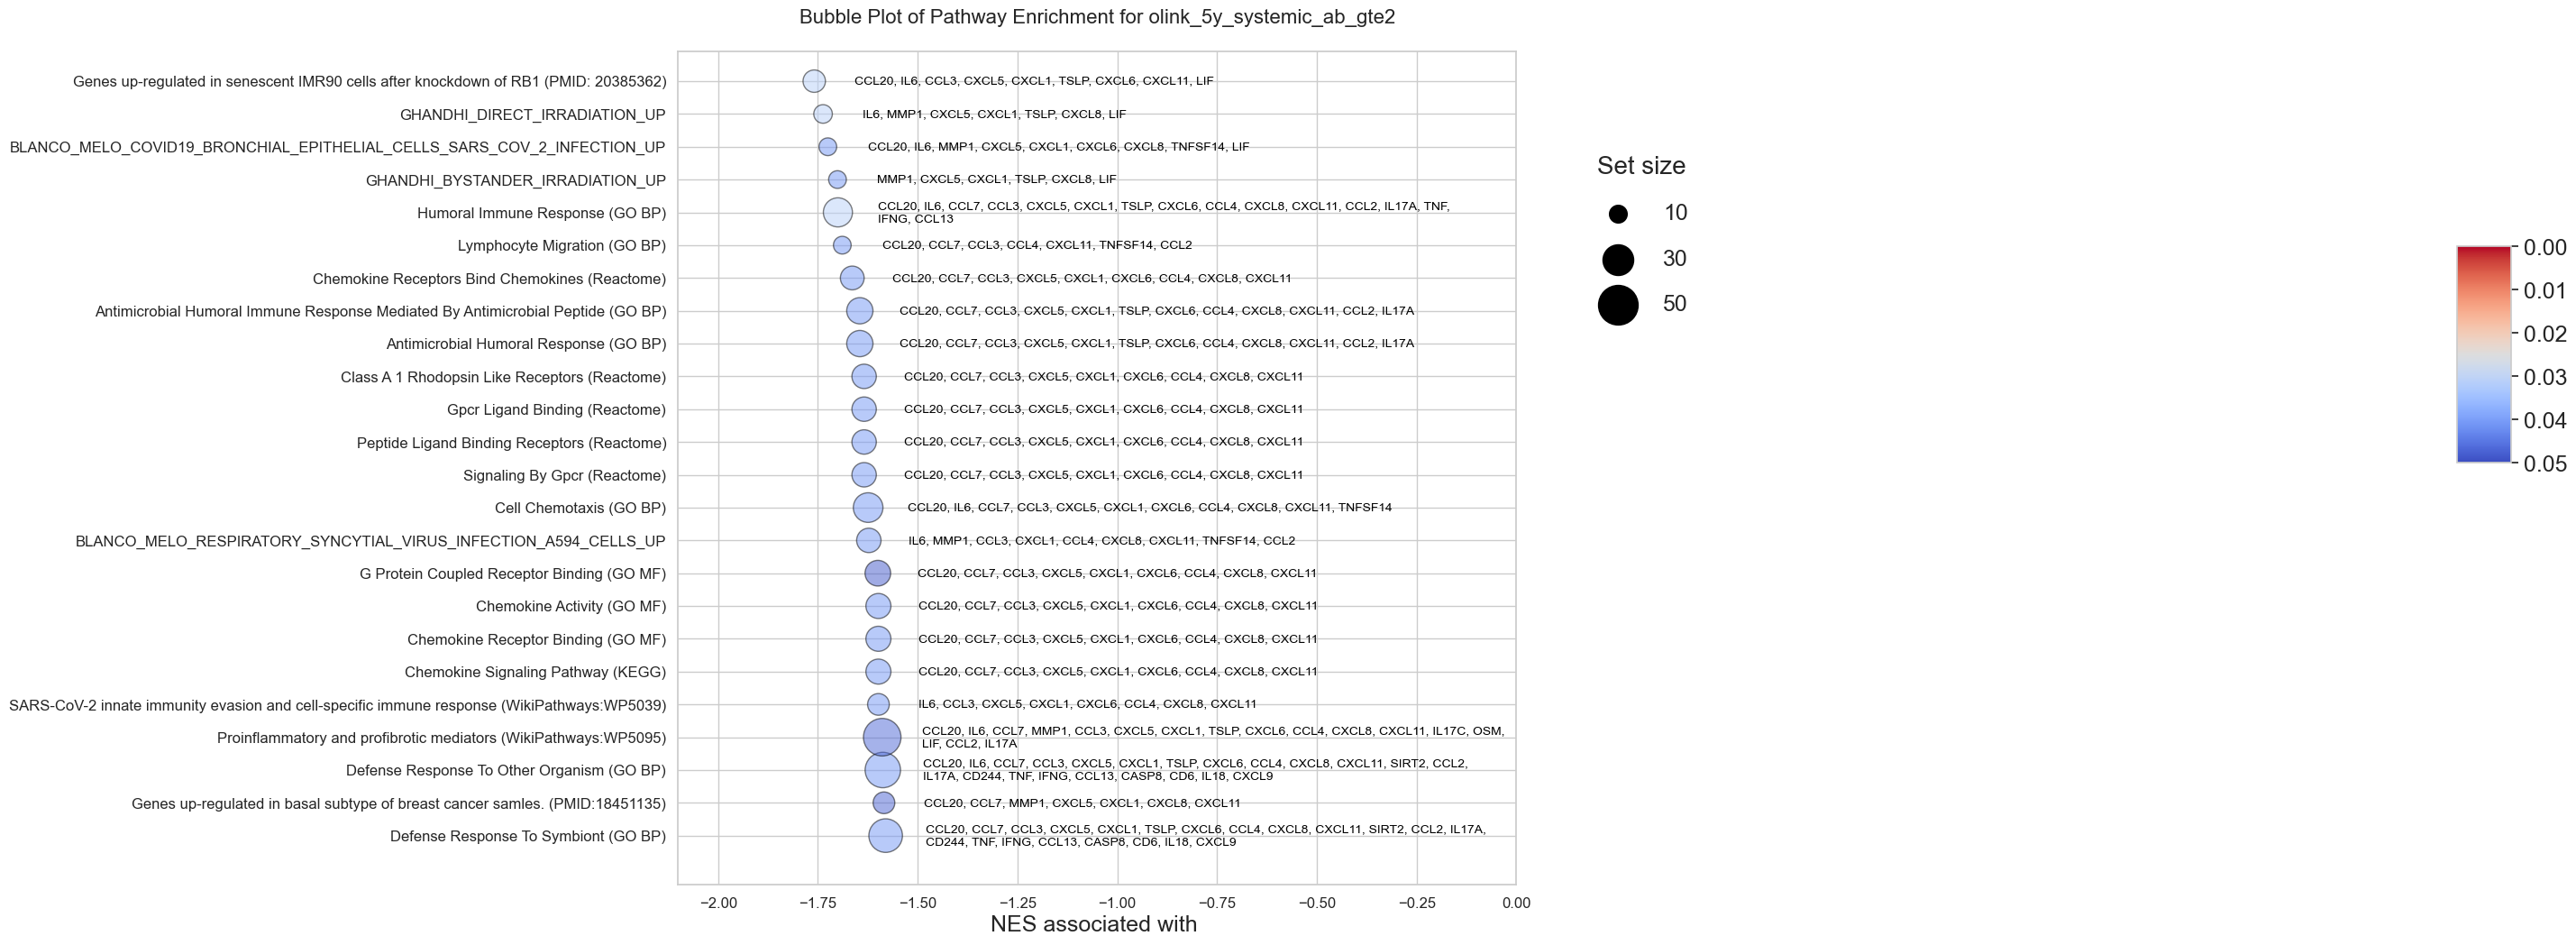

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 8,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 12,               # Font size for x-axis tick labels
    'ytick.labelsize': 12,               # Font size for y-axis tick labels
    'legend.fontsize': 8,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_5y_systemic_ab_gte2)
df = df.tail(25)
# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 12))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] *20,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    core_text = row['core_enrichment']
    
    # Wrap text if it's longer than 90 characters
    if len(core_text) > 60:
        core_text = '\n'.join(textwrap.wrap(core_text, 90))
    
    ax.text(
        row['NES'] + 0.1,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        core_text,  # Display comma-delimited core enrichment genes
        va='center', ha='left', fontsize=10, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Manually set the position of the colorbar
cbar_ax = fig.add_axes([1.77, 0.5, 0.05, 0.2])  # Adjust these values for position and size
cbar = fig.colorbar(sm, cax=cbar_ax)  # Use the new axes for the colorbar

# Set colorbar ticks
cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # Set colorbar ticks
cbar.ax.invert_yaxis()  # Invert so that red is at the top and blue is at the bottom

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=18)

# Set horizontal colorbar label below the colorbar
cbar.ax.set_xlabel('', fontsize=5)
cbar.ax.xaxis.set_label_position('top')  # Set the position of the label
cbar.ax.xaxis.labelpad = 3  # Adjust the padding to create space between colorbar and label

# Add labels and title
ax.set_xlabel('NES associated with ', fontsize=18)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_5y_systemic_ab_gte2\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 30, 50]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 20, c='black', edgecolor='black', label=f'{size}')

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Set size', loc='upper left', bbox_to_anchor=(1.07, 0.90), 
    title_fontsize=20, fontsize=18, frameon=False, handletextpad=1, labelspacing=1.1
)

# Set x-axis limits
ax.set_xlim(-2.1, 0)  # Set x-axis limits
ax.set_ylim(-1.5, len(df) - 0.1)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
#plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


# 5-year pathways and use of 2 OR MORE systemic antibiotic courses between birth and 1 year of age (allergy med use removed)

In [ ]:
olink_5y_systemic_ab_gte2 = pd.read_csv("olink_gsea_5y_systemic_ab_gte2_medsremoved_results.csv")
olink_5y_systemic_ab_gte2['visit']='5 Years'
# Invert the NES to indicate change relative to the no exposure
olink_5y_systemic_ab_gte2['NES'] = olink_5y_systemic_ab_gte2['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].apply(clean_description)
olink_5y_systemic_ab_gte2.sort_values(by="NES",inplace=True, ascending=False)

olink_5y_systemic_ab_gte2.reset_index(drop=True, inplace=True)

for index, row in olink_5y_systemic_ab_gte2.iterrows():
    olink_5y_systemic_ab_gte2.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_OVERVIEW_OF_PROINFLAMMATORY_AND_PROFIBROTIC_MEDIATORS","Proinflammatory and profibrotic mediators (WikiPathways:WP5095)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_NETWORK_MAP_OF_SARSCOV2_SIGNALING"," SARS-CoV-2 signaling (WikiPathways:WP5115)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("GAURNIER_PSMD4_TARGETS","Cytokines and their cognate receptors up-regulated in THP-1 cells (monocyte) after treatment with PSMD4 (PMID:18632645)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("SANA_TNF_SIGNALING_UP","Genes up-regulated in five primary endothelial cell types (lung, aortic, iliac, dermal, and colon) by TNF(PMID:15749026)",inplace=True)


olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("LINDSTEDT_DENDRITIC_CELL_MATURATION_A","Maturation of monocyte-derived dendritic cells (DC) in response to inflammatory stimuli: (PMID:12356685)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("MCLACHLAN_DENTAL_CARIES_UP","Genes up-regulated in pulpal tissue extracted from carious teeth (PMID:15869869)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("SMID_BREAST_CANCER_BASAL_UP","Genes up-regulated in basal subtype of breast cancer samles. (PMID:18451135)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("BLANCO_MELO_HUMAN_PARAINFLUENZA_VIRUS_3_INFECTION_A594_CELLS_UP","Genes up-regulated in response to HPIV3 (A549 cells): (PMID:32416070)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_SARSCOV2_INNATE_IMMUNITY_EVASION_AND_CELLSPECIFIC_IMMUNE_RESPONSE","SARS-CoV-2 innate immunity evasion and cell-specific immune response (WikiPathways:WP5039)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("WP_CHEMOKINE_SIGNALING","Chemokine signaling (WikiPathways:WP3929)",inplace=True)
olink_5y_systemic_ab_gte2['Description'] = olink_5y_systemic_ab_gte2['Description'].replace("CHICAS_RB1_TARGETS_SENESCENT","Genes up-regulated in senescent IMR90 cells after knockdown of RB1 (PMID: 20385362)",inplace=True)


In [ ]:
import pandas as pd

# Read cytokine data file
cytokine_file = 'ttest_results_5y_systemic_ab_gte2medsremoved.csv'  # Change this filename as needed
cytokine_df = pd.read_csv(cytokine_file)

# Calculate change (column '1' - column '0')
cytokine_df['change'] = cytokine_df['1'] - cytokine_df['0']

# Create a dictionary mapping assay name to change value
change_dict = dict(zip(cytokine_df['Assay'], cytokine_df['change']))

# Count how many pathways each chemokine appears in
chemokine_counts = {}
for enrichment_list in olink_5y_systemic_ab_gte2['core_enrichment']:
    chemokines = [c.strip() for c in enrichment_list.split(',')]
    for chemokine in chemokines:
        chemokine_counts[chemokine] = chemokine_counts.get(chemokine, 0) + 1

# Sort by change value (largest to smallest)
n_pathways = len(olink_5y_systemic_ab_gte2)
sorted_chemokines = sorted(
    chemokine_counts.items(), 
    key=lambda x: change_dict.get(x[0], float('-inf')), 
    reverse=True
)

print(f"Chemokines sorted by change (across {n_pathways} pathways):")
print("-" * 70)
ordered_list = []
for chemokine, count in sorted_chemokines:
    
    pct = (count / n_pathways) * 100
    if pct >=50:
        ordered_list.append(chemokine)
        change = change_dict.get(chemokine, 'N/A')
        change_str = f"{change:.3f}" if isinstance(change, (int, float)) else change
        print(f"{chemokine:30s} {count}/{n_pathways} ({pct:.1f}%)  change: {change_str}")
print("\n")
for chemokine in ordered_list:
    print(chemokine, end=", ")

Chemokines sorted by change (across 24 pathways):
----------------------------------------------------------------------
CXCL11                         21/24 (87.5%)  change: -0.262
CXCL8                          22/24 (91.7%)  change: -0.284
CCL4                           19/24 (79.2%)  change: -0.293
CXCL6                          19/24 (79.2%)  change: -0.294
CXCL1                          23/24 (95.8%)  change: -0.305
CXCL5                          22/24 (91.7%)  change: -0.383
CCL3                           20/24 (83.3%)  change: -0.421
CCL7                           18/24 (75.0%)  change: -0.459
CCL20                          20/24 (83.3%)  change: -0.543


CXCL11, CXCL8, CCL4, CXCL6, CXCL1, CXCL5, CCL3, CCL7, CCL20, 

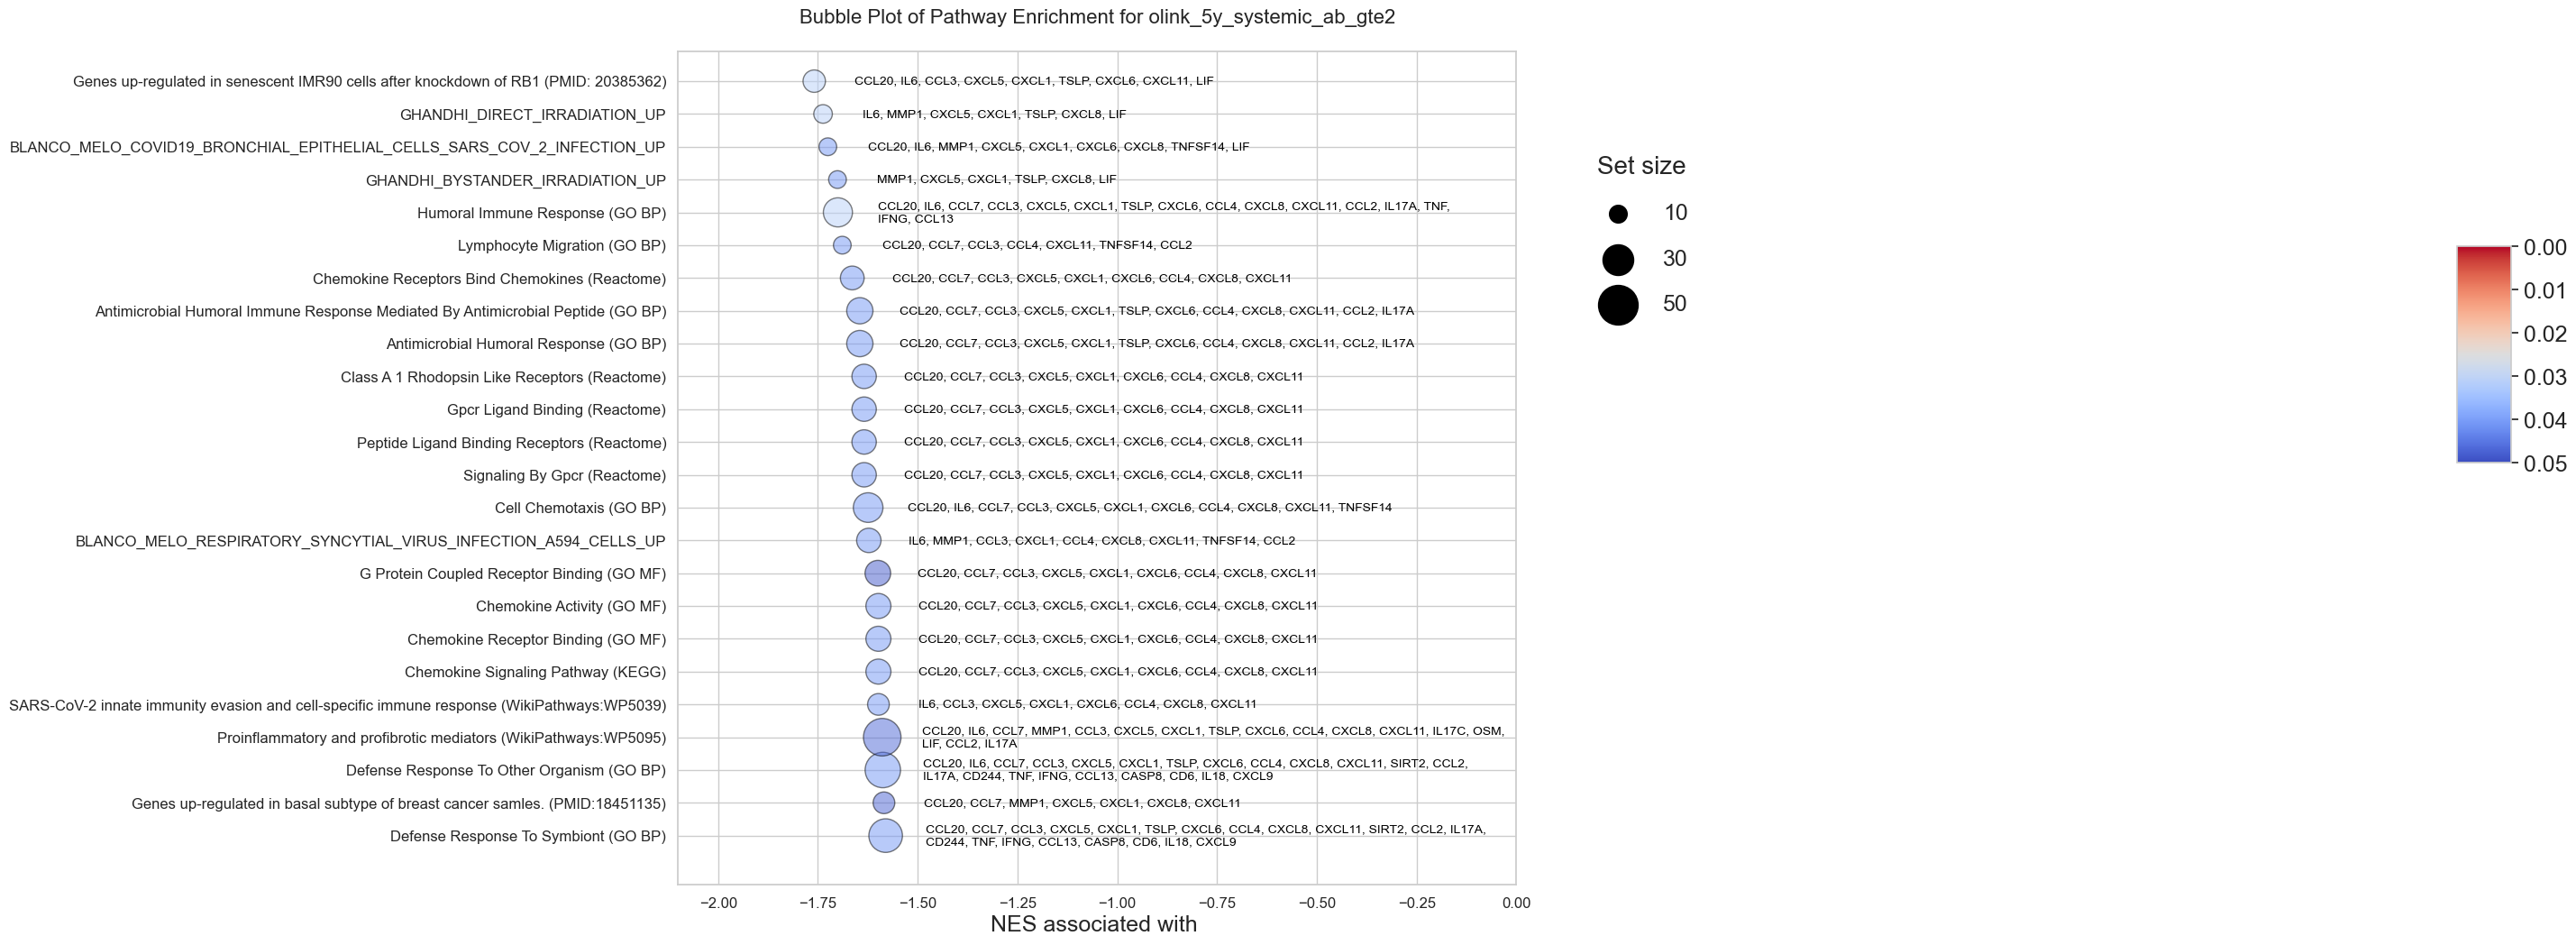

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 8,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 12,               # Font size for x-axis tick labels
    'ytick.labelsize': 12,               # Font size for y-axis tick labels
    'legend.fontsize': 8,               # Font size for legend
    'figure.titlesize': 18               # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_5y_systemic_ab_gte2)
df = df.tail(25)
# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 12))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)

# Create a color map that goes from red (low p.adjust) to blue (high p.adjust)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Using a red-to-blue palette, reversed

# Scatter plot (bubble plot) with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] *20,  # Adjust bubble size scaling factor
    alpha=0.5, 
    edgecolor='black', 
    c=colors  # Use the colors based on p.adjust
)

# Add the core enrichment genes as text next to each bubble
for i, row in df.iterrows():
    core_text = row['core_enrichment']
    
    # Wrap text if it's longer than 90 characters
    if len(core_text) > 60:
        core_text = '\n'.join(textwrap.wrap(core_text, 90))
    
    ax.text(
        row['NES'] + 0.1,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        core_text,  # Display comma-delimited core enrichment genes
        va='center', ha='left', fontsize=10, color='black'
    )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
sm.set_array([])  # Required to create the colorbar

# Manually set the position of the colorbar
cbar_ax = fig.add_axes([1.77, 0.5, 0.05, 0.2])  # Adjust these values for position and size
cbar = fig.colorbar(sm, cax=cbar_ax)  # Use the new axes for the colorbar

# Set colorbar ticks
cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # Set colorbar ticks
cbar.ax.invert_yaxis()  # Invert so that red is at the top and blue is at the bottom

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=18)

# Set horizontal colorbar label below the colorbar
cbar.ax.set_xlabel('', fontsize=5)
cbar.ax.xaxis.set_label_position('top')  # Set the position of the label
cbar.ax.xaxis.labelpad = 3  # Adjust the padding to create space between colorbar and label

# Add labels and title
ax.set_xlabel('NES associated with ', fontsize=18)
ax.set_ylabel('', fontsize=14)
ax.set_title('Bubble Plot of Pathway Enrichment for olink_5y_systemic_ab_gte2\n', fontsize=16)

# Create a custom legend for bubble sizes, proportional to actual bubbles
legend_sizes = [10, 30, 50]  # Example bubble sizes (number of genes)
for size in legend_sizes:
    ax.scatter([], [], s=size * 20, c='black', edgecolor='black', label=f'{size}')

# Add the custom legend for bubble sizes below the colorbar without a border
leg = ax.legend(
    title='Set size', loc='upper left', bbox_to_anchor=(1.07, 0.90), 
    title_fontsize=20, fontsize=18, frameon=False, handletextpad=1, labelspacing=1.1
)

# Set x-axis limits
ax.set_xlim(-2.1, 0)  # Set x-axis limits
ax.set_ylim(-1.5, len(df) - 0.1)  # Adjust y-axis limits to fit all bubbles

# Adjust layout to make space for the colorbar
#plt.tight_layout(rect=[0, 0, 0.85, 1])

# Display plot
plt.show()


# Home cleaned more than 4 times per month (birth-3m)
Pathways were only enriched for the 5-year time point

In [ ]:
olink_1y_home_cleaned_greater_than_3times_per_month = pd.read_csv("olink_1y_clean_home_more_than_4_times_per_month.csv")
olink_1y_home_cleaned_greater_than_3times_per_month['visit']='1 Year'
# Invert the NES to indicate change relative to the no exposure
olink_1y_home_cleaned_greater_than_3times_per_month['NES'] = olink_1y_home_cleaned_greater_than_3times_per_month['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_1y_home_cleaned_greater_than_3times_per_month['Description'] = olink_1y_home_cleaned_greater_than_3times_per_month['Description'].apply(clean_description)
olink_1y_home_cleaned_greater_than_3times_per_month.sort_values(by="NES",inplace=True, ascending=False)


olink_5y_home_cleaned_greater_than_3times_per_month = pd.read_csv("olink_5y_clean_home_more_than_4_times_per_month.csv")
olink_5y_home_cleaned_greater_than_3times_per_month['visit']='5 Years'
# Invert the NES to indicate change relative to the no exposure
olink_5y_home_cleaned_greater_than_3times_per_month['NES'] = olink_5y_home_cleaned_greater_than_3times_per_month['NES'] * -1


# Apply the cleaning function to the 'Description' column
olink_5y_home_cleaned_greater_than_3times_per_month['Description'] = olink_5y_home_cleaned_greater_than_3times_per_month['Description'].apply(clean_description)
olink_5y_home_cleaned_greater_than_3times_per_month.sort_values(by="NES",inplace=True, ascending=False)


In [ ]:
dataframes = [olink_1y_home_cleaned_greater_than_3times_per_month,olink_5y_home_cleaned_greater_than_3times_per_month]

olink_1y_and_5y_home_cleaned_greater_than_3times_per_month = pd.concat(dataframes)

In [ ]:
for index, row in olink_1y_and_5y_home_cleaned_greater_than_3times_per_month.iterrows():
    olink_1y_and_5y_home_cleaned_greater_than_3times_per_month.loc[index, 'core_enrichment'] = row['core_enrichment'].replace("/",", ")

olink_1y_and_5y_home_cleaned_greater_than_3times_per_month.sort_values(by="NES",inplace=True, ascending=False)
olink_1y_and_5y_home_cleaned_greater_than_3times_per_month.reset_index(drop=True, inplace=True)

# Supplementary figure 10c: 1-year pathways and clean home more than 4 times per month.

In [ ]:
olink_home_cleaned_greater_than_3times_per_month_1y = olink_1y_and_5y_home_cleaned_greater_than_3times_per_month[olink_1y_and_5y_home_cleaned_greater_than_3times_per_month['visit']=='1 Year']

olink_home_cleaned_greater_than_3times_per_month_5y = olink_1y_and_5y_home_cleaned_greater_than_3times_per_month[olink_1y_and_5y_home_cleaned_greater_than_3times_per_month['visit']=='5 Years']

olink_home_cleaned_greater_than_3times_per_month_5y['Description'].replace("BLANCO_MELO_COVID19_SARS_COV_2_INFECTION_CALU3_CELLS_UP","Genes up-regulated in Calu-3 cells due to\nSARS-CoV-2 infection (PMID:32416070)",inplace=True)


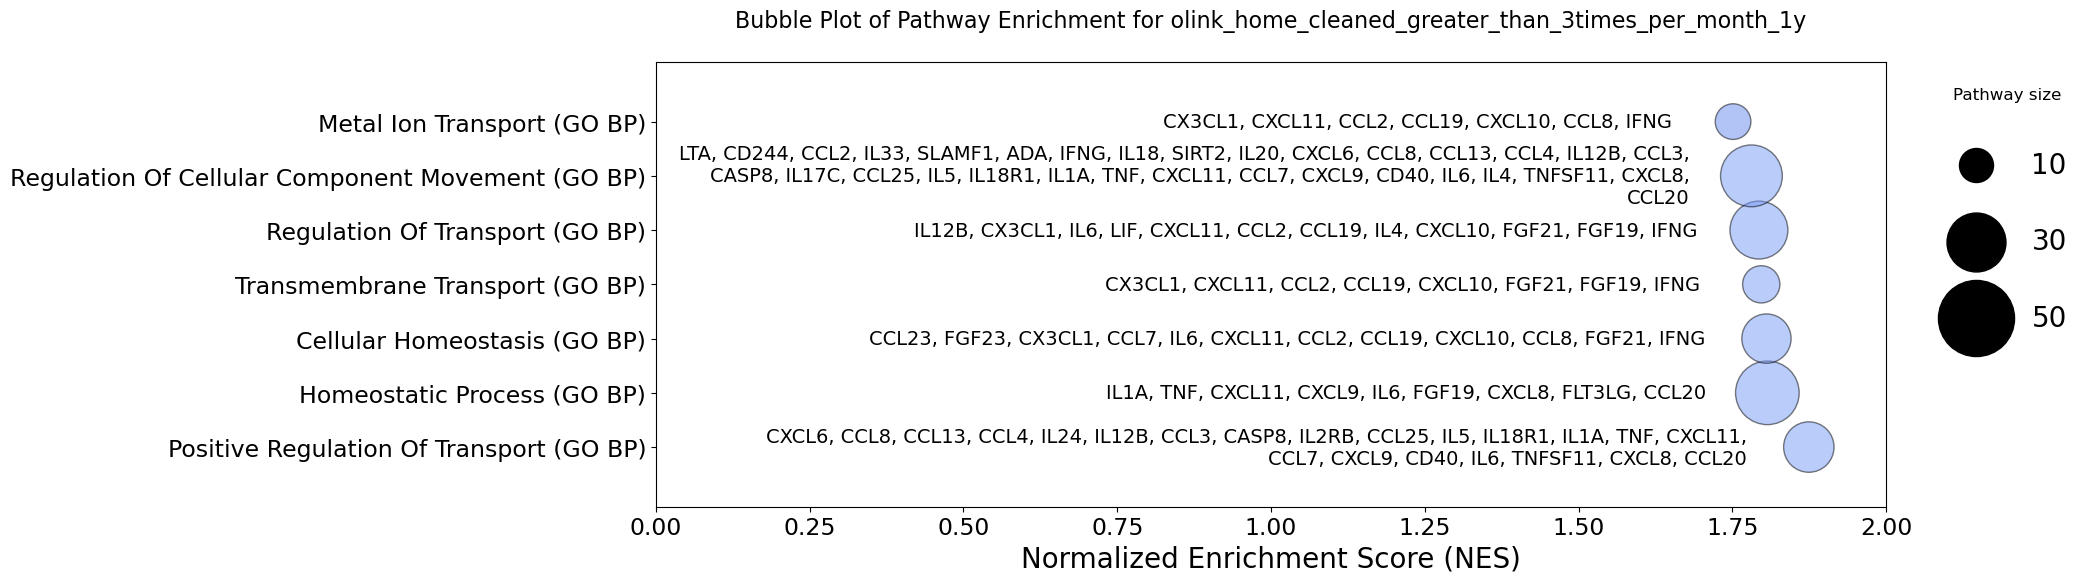

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 12,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 17,               # Font size for x-axis tick labels
    'ytick.labelsize': 17,               # Font size for y-axis tick labels
    'legend.fontsize': 12,               # Font size for legend
    'figure.titlesize': 18                # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_home_cleaned_greater_than_3times_per_month_1y)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

 #Assuming 'setSize' is a column in your DataFrame
# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(25, 6))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Color map

# Scatter plot with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 60,
    alpha=0.5, 
    edgecolor='black', 
    c=colors
)

for i, row in df.iterrows():
    core_text = row['core_enrichment']
    
    # Wrap text if it's longer than 200 characters
    if len(core_text) > 100:
        core_text = '\n'.join(textwrap.wrap(core_text, 100))
    
    ax.text(
        row['NES'] - 0.1,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        core_text,  # Display comma-delimited core enrichment genes
        va='center', ha='right', fontsize=14, color='black'
    )

# Create colorbar
#sm = plt.cm.ScalarMappable(cmap='coolwarm_r', norm=norm)
#sm.set_array([])
#cbar_ax = fig.add_axes([0.77, 0.3, 0.02, 0.2])
#cbar = fig.colorbar(sm, cax=cbar_ax)
#cbar.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])
#cbar.ax.invert_yaxis()
#cbar.ax.tick_params(labelsize=10)
#cbar.ax.set_xlabel('Adjusted\np-value', fontsize=12, labelpad=10)

# Add labels, title, and legend
ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=20)
ax.set_ylabel('')
ax.set_title('Bubble Plot of Pathway Enrichment for olink_home_cleaned_greater_than_3times_per_month_1y\n', fontsize=16)

# Legend for bubble sizes
legend_sizes = [10, 30,50]
for size in legend_sizes:
    ax.scatter([], [], s=size * 60, c='black', edgecolor='black', label=f'{size}')
leg = ax.legend(title='Pathway size', loc='upper left', bbox_to_anchor=(1.03, 1.0), 
                title_fontsize=12, fontsize=20, frameon=False, handletextpad=1, labelspacing=1.75)
# Set x-axis limits
ax.set_xlim(0, 2)  # Set x-axis limits
# Display plot
ax.set_ylim(-1.1, len(df)+0.1 )
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the colorbar
plt.show()

# Supplementary figure 10d: 5-year pathways and clean home more than 4 times per month.

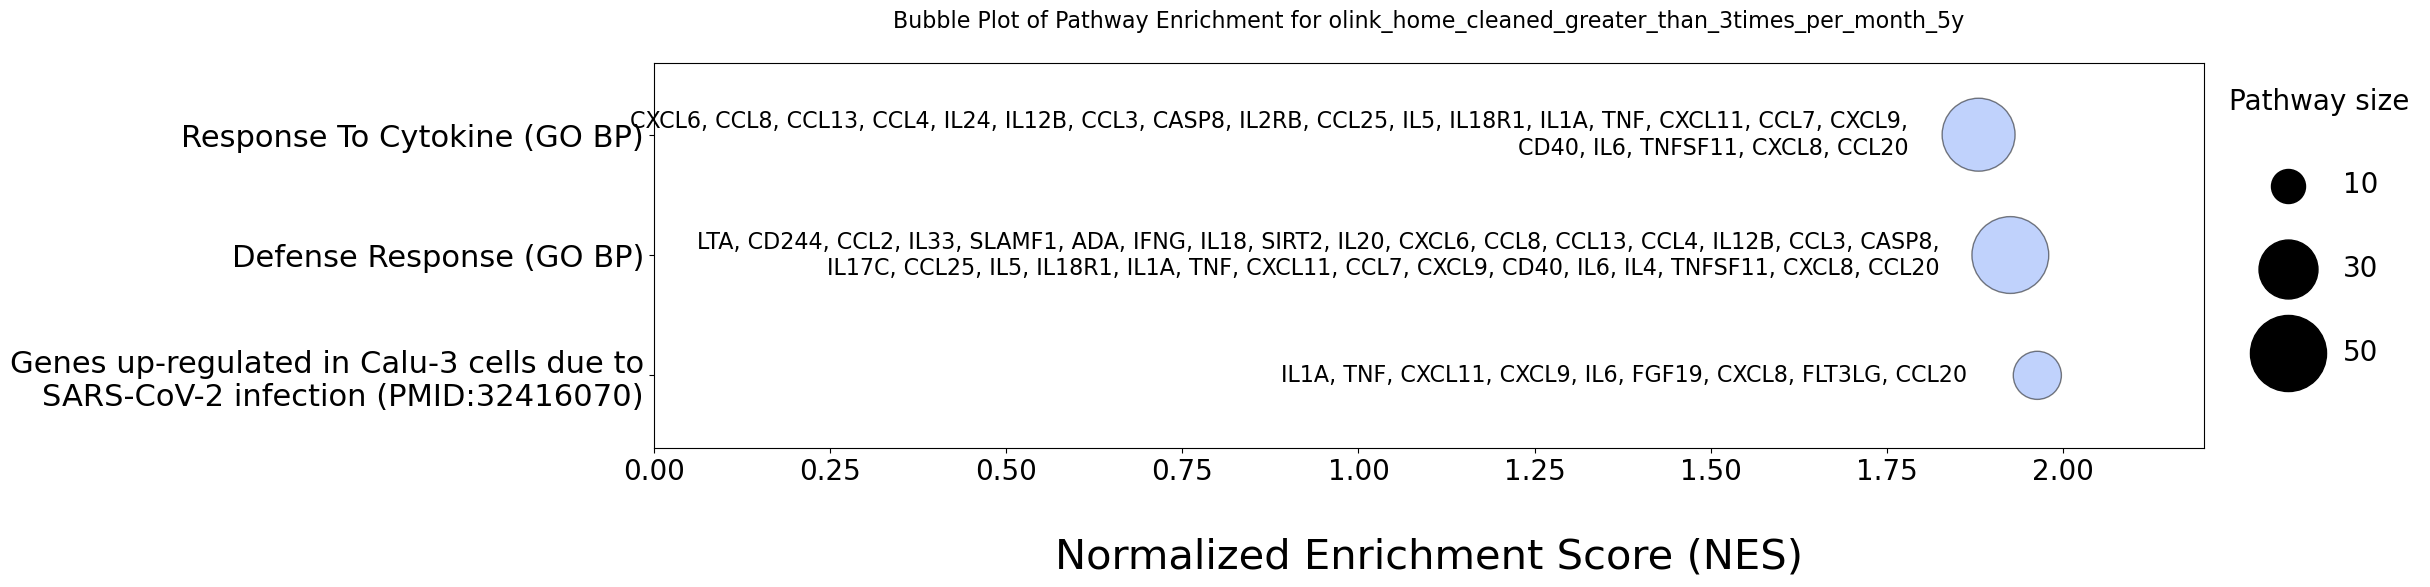

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Customize font settings for the plot
plt.rcParams.update({
    'font.family': 'sans serif',         # Customize font family
    'font.size': 12,                     # Default font size
    'axes.titlesize': 16,                # Font size for title
    'axes.labelsize': 12,                # Font size for axis labels
    'xtick.labelsize': 20,               # Font size for x-axis tick labels
    'ytick.labelsize': 22,               # Font size for y-axis tick labels
    'legend.fontsize': 12,               # Font size for legend
    'figure.titlesize': 18                # Font size for overall figure title
})

# Convert to DataFrame
df = pd.DataFrame(olink_home_cleaned_greater_than_3times_per_month_5y)

# Calculate the size of the bubble proportional to the number of genes in core_enrichment
df['core_enrichment_size'] = df['core_enrichment'].apply(lambda x: len(x.split(',')))

 #Assuming 'setSize' is a column in your DataFrame
# Calculate the percentage of core enrichment genes relative to setSize
df['core_enrichment_percentage'] = df['core_enrichment_size'] / df['setSize'] * 100  # in percentage

# Set up the figure
fig, ax = plt.subplots(figsize=(20, 5))

# Normalize p.adjust to the range (0, 0.05) for the color scale
norm = plt.Normalize(vmin=0, vmax=0.05)
colors = plt.cm.coolwarm_r(norm(df['p.adjust']))  # Color map

# Scatter plot with colors based on p.adjust
bubble_plot = ax.scatter(
    x=df['NES'], 
    y=df['Description'], 
    s=df['setSize'] * 60,
    alpha=0.5, 
    edgecolor='black', 
    c=colors
)

for i, row in df.iterrows():
    core_text = row['core_enrichment']
    
    # Wrap text if it's longer than 200 characters
    if len(core_text) > 110:
        core_text = '\n'.join(textwrap.wrap(core_text, 110))
    
    ax.text(
        row['NES'] - 0.1,  # Small offset to the right of each bubble
        row['Description'],  # Align y-position with the bubble's y-axis label
        core_text,  # Display comma-delimited core enrichment genes
        va='center', ha='right', fontsize=16, color='black'
    )




# Add labels, title, and legend
ax.set_xlabel('\nNormalized Enrichment Score (NES)', fontsize=30)
ax.set_ylabel('')
ax.set_title('Bubble Plot of Pathway Enrichment for olink_home_cleaned_greater_than_3times_per_month_5y\n', fontsize=16)

# Legend for bubble sizes
legend_sizes = [10, 30,50]
for size in legend_sizes:
    ax.scatter([], [], s=size * 60, c='black', edgecolor='black', label=f'{size}')
leg = ax.legend(title='Pathway size', loc='upper left', bbox_to_anchor=(1.0, 1.0), 
                title_fontsize=20, fontsize=20, frameon=False, handletextpad=1, labelspacing=2)

# Set x-axis limits
ax.set_xlim(0, 2.2)  # Set x-axis limits
# Display plot
ax.set_ylim(-0.6, len(df)-0.4 )
#plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the colorbar
plt.show()